In [3]:
import sys
#sys.path.insert(1, '/home/santolam/MyPythonLibrary/MAR-RECAP/libmar/')
sys.path.insert(1, '/home/fainx/MyPythonLibrary/MAR-RECAP/libmar/')
#sys.path.insert(1, '/Users/santolam/Documents/MyPythonLibrary/MAR-RECAP/libmar/')
import climbasis as climb
from climbasis import *
import domain as dom
import myplot
import numpy.ma as ma
from myplot import *
import obsinfo as obs
from obsinfo import *
from datetime import datetime
import mar
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
from scipy.stats import pearsonr, spearmanr, linregress
import pandas as pd

In [4]:
iyr=1980;fyr=2024
domain='GRf'
latS,latN,lonW,lonE,latlim,lonlim=dom.coord_domain(domain)  
print(latS,latN,lonW,lonE)

# Removed pixels on domain boundaries
k =10

36 41 67 78


In [5]:
# Jasgulem ice core coordinates:
jasg_lat = 38.54063
jasg_lon = 72.269816

In [6]:
season_list = ["DJF", "MAM", "JJA", "SON"]

In [7]:
domain_2 = 'GRp'
# domain_3 = 'GRp_bug'

In [8]:
sourceData_1='/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/' + domain_2 +'/spin2/work/monthly/'
sourceData_2='/bettik/PROJECTS/pr-regional-climate/fainx/'
sourceData_3='/bettik/PROJECTS/pr-regional-climate/santolam/HARv2/'
folder_figure = '/bettik/PROJECTS/pr-regional-climate/fainx/figures/' + domain_2 +'/'

In [9]:
# MAR topography
sourceDataGrid='/home/amoryc/'
fileName_grF='NST.2000.01.01.00.GRp.nc'
ds_grF= xr.open_dataset(sourceDataGrid+fileName_grF)

# Enlever k pixels sur les contours
ds_lon=ds_grF.LON[k:-k,k:-k]
ds_lat=ds_grF.LAT[k:-k,k:-k]
ds_SH=ds_grF.SH[k:-k,k:-k]
ds_ICE=ds_grF.ICE[k:-k,k:-k]

ds_lon = ds_lon.rename({"y": "Y", "x": "X"})
ds_lat = ds_lat.rename({"y": "Y", "x": "X"})
ds_SH = ds_SH.rename({"y": "Y", "x": "X"})
ds_ICE = ds_ICE.rename({"y": "Y", "x": "X"})

ds_lon = ds_lon.assign_coords(X=np.round(ds_lon.X.values))
ds_lon = ds_lon.assign_coords(Y=np.round(ds_lon.Y.values))

ds_lat = ds_lat.assign_coords(X=np.round(ds_lat.X.values))
ds_lat = ds_lat.assign_coords(Y=np.round(ds_lat.Y.values))

ds_SH = ds_SH.assign_coords(X=np.round(ds_SH.X.values))
ds_SH = ds_SH.assign_coords(Y=np.round(ds_SH.Y.values))

ds_ICE = ds_ICE.assign_coords(X=np.round(ds_ICE.X.values))
ds_ICE = ds_ICE.assign_coords(Y=np.round(ds_ICE.Y.values))

In [10]:
# Identifier les indices X et Y correspondant au point de grille ou se trouve la carotte Jasgulem

# distance sur grille
dist = np.sqrt((ds_lat - jasg_lat)**2 + (ds_lon - jasg_lon)**2)

# index 1D du minimum
idx_1d = dist.argmin().item()

# conversion en indices 2D (Y, X)
iY, iX = np.unravel_index(idx_1d, dist.shape)

print("Caratéristique de la maille MAR ou se trouve le forage 2025")
print("Indice Y :", iY)
print("Indice X :", iX)
print("Latitude :", ds_lat[iY, iX].item())
print("Longitude :", ds_lon[iY, iX].item())
print("Altitude :", ds_SH[iY, iX].item())

Caratéristique de la maille MAR ou se trouve le forage 2025
Indice Y : 26
Indice X : 47
Latitude : 38.54820251464844
Longitude : 72.30000305175781
Altitude : 5300.28369140625


/tmp/ipykernel_513390/2256675531.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


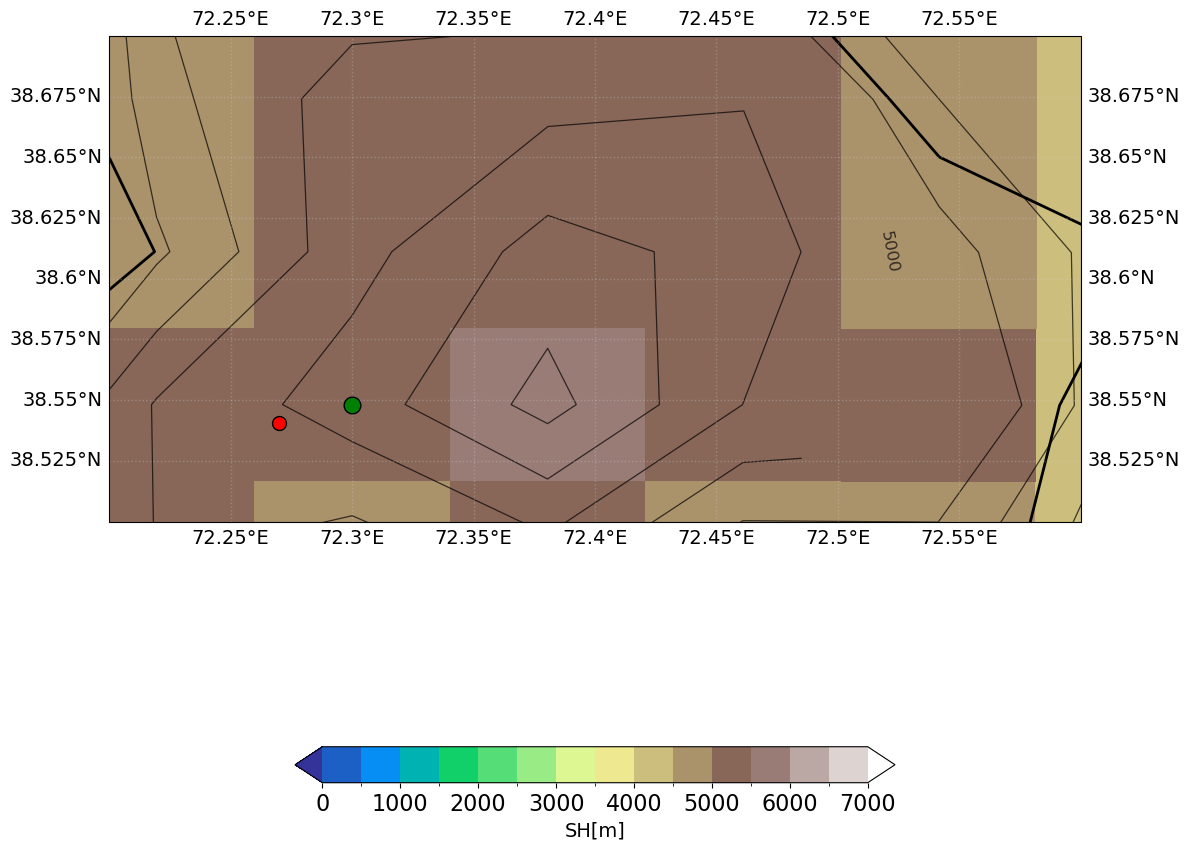

In [11]:
ice_level=32# % of ice on grid cell

clevs=np.arange(0,7500,500)
cmap_mod = plt.get_cmap('terrain')
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap_mod.N, extend="both")

fig, ax = plt.subplots(figsize=(12, 12),
                         subplot_kw={'projection': ccrs.PlateCarree()})


im = ax.pcolormesh(ds_lon, ds_lat, ds_SH,
                       transform=ccrs.PlateCarree(), cmap=cmap_mod,norm=norm,shading='auto')
# ax.add_feature(cfeature.COASTLINE)
# ax.add_feature(cfeature.BORDERS, linestyle=':')

# ICE1=ax.contourf(ds_lon, ds_lat,ds_ICE,
#             levels=[10,ice_level,100],
#             hatches=['','X','X'],
#             colors="none",
#             transform=ccrs.PlateCarree())

#    ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', linestyle='--')
ax.set_aspect(1.0)
SH1 = ax.contour(ds_lon, ds_lat, ds_SH,
                             levels=[4400,4600,4800,5000,5200,5400,5600,5800,6000,6200,6400,6600,6800,7000],
                             colors="k", linewidths=0.9, alpha=0.7,
                             transform=ccrs.PlateCarree())
ax.clabel(SH1, inline=True, fontsize=12, fmt="%d")
    
ICE2= ax.contour(ds_lon, ds_lat, ds_ICE,
                    levels=[ice_level],
                    colors="black", linewidths=2.0, alpha=1.0,
                    transform=ccrs.PlateCarree())

ax.clabel(ICE2, inline=True, fontsize=16, fmt="%d")
 
ax.set_extent([72.2, 72.6, 38.5, 38.7], crs=ccrs.PlateCarree())

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=1, color="lightgray", alpha=0.3, linestyle=":")
gl.xlabel_style = {"size": 14}
gl.ylabel_style = {"size": 14}

  
cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.03])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal")
cbar.set_label(f"{'SH'}[{'m'}]", fontsize=14)
cbar.ax.tick_params(labelsize=16)

fig.subplots_adjust(left=0.2, right=0.8, top=0.95, bottom=0.1, wspace=0.05, hspace=0.2)
plt.tight_layout()

# Jasgulem ice core : red dot
ax.plot(jasg_lon, jasg_lat,
        marker='o', markersize=10,
        markeredgecolor='black', markerfacecolor='red',
        transform=ccrs.PlateCarree())

# Identifier le point de grille ou se trouve la carotte Jasgulem
ax.plot(ds_lon[iY, iX], ds_lat[iY, iX],
        marker='o', markersize=12,
        markeredgecolor='black', markerfacecolor='green',
        transform=ccrs.PlateCarree())

plt.show()

/tmp/ipykernel_513390/3268150799.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


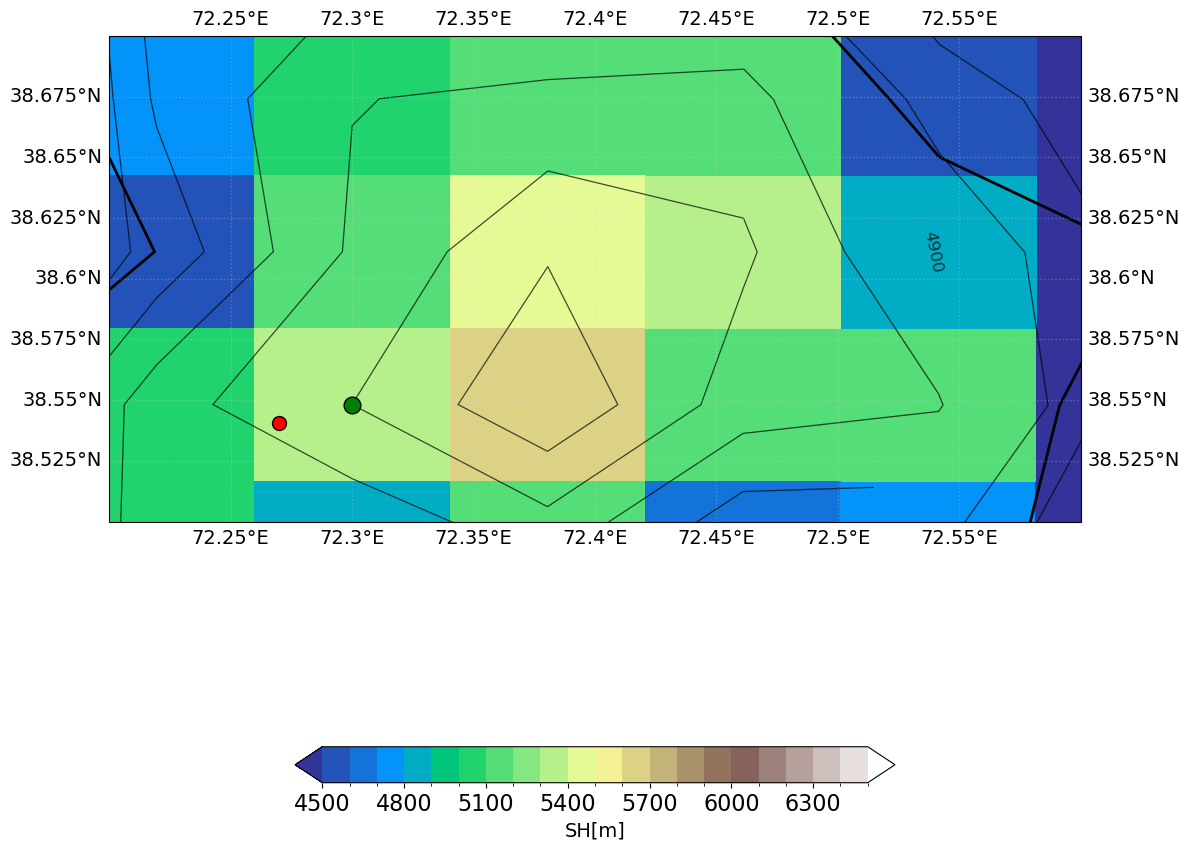

In [12]:
# Niveaux d'altitude entre 4500 et 6500 mètres
clevs = np.arange(4500, 6501, 100)  # Incréments de 100 m pour une transition progressive
cmap_mod = plt.get_cmap('terrain')
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap_mod.N, extend="both")

fig, ax = plt.subplots(figsize=(12, 12), subplot_kw={'projection': ccrs.PlateCarree()})

im = ax.pcolormesh(ds_lon, ds_lat, ds_SH,
                    transform=ccrs.PlateCarree(),
                    cmap=cmap_mod,
                    norm=norm,
                    shading='auto')

# Contours pour les altitudes
SH1 = ax.contour(ds_lon, ds_lat, ds_SH,
                 levels=np.arange(4500, 6501, 200),  # Niveaux de contours tous les 200 m
                 colors="k",
                 linewidths=0.9,
                 alpha=0.7,
                 transform=ccrs.PlateCarree())
ax.clabel(SH1, inline=True, fontsize=12, fmt="%d")

# Contours pour la glace
ICE2 = ax.contour(ds_lon, ds_lat, ds_ICE,
                  levels=[ice_level],
                  colors="black",
                  linewidths=2.0,
                  alpha=1.0,
                  transform=ccrs.PlateCarree())
ax.clabel(ICE2, inline=True, fontsize=16, fmt="%d")

# Étendue géographique
ax.set_extent([72.2, 72.6, 38.5, 38.7], crs=ccrs.PlateCarree())

# Grilles et étiquettes
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color="lightgray", alpha=0.3, linestyle=":")
gl.xlabel_style = {"size": 14}
gl.ylabel_style = {"size": 14}

# Barre de couleur
cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.03])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal")
cbar.set_label(f"{'SH'}[{'m'}]", fontsize=14)
cbar.ax.tick_params(labelsize=16)

# Ajustement des sous-graphiques
fig.subplots_adjust(left=0.2, right=0.8, top=0.95, bottom=0.1, wspace=0.05, hspace=0.2)
plt.tight_layout()

# Points spécifiques
ax.plot(jasg_lon, jasg_lat,
        marker='o', markersize=10,
        markeredgecolor='black', markerfacecolor='red',
        transform=ccrs.PlateCarree())

ax.plot(ds_lon[iY, iX], ds_lat[iY, iX],
        marker='o', markersize=12,
        markeredgecolor='black', markerfacecolor='green',
        transform=ccrs.PlateCarree())

plt.show()

/tmp/ipykernel_513390/4011659233.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


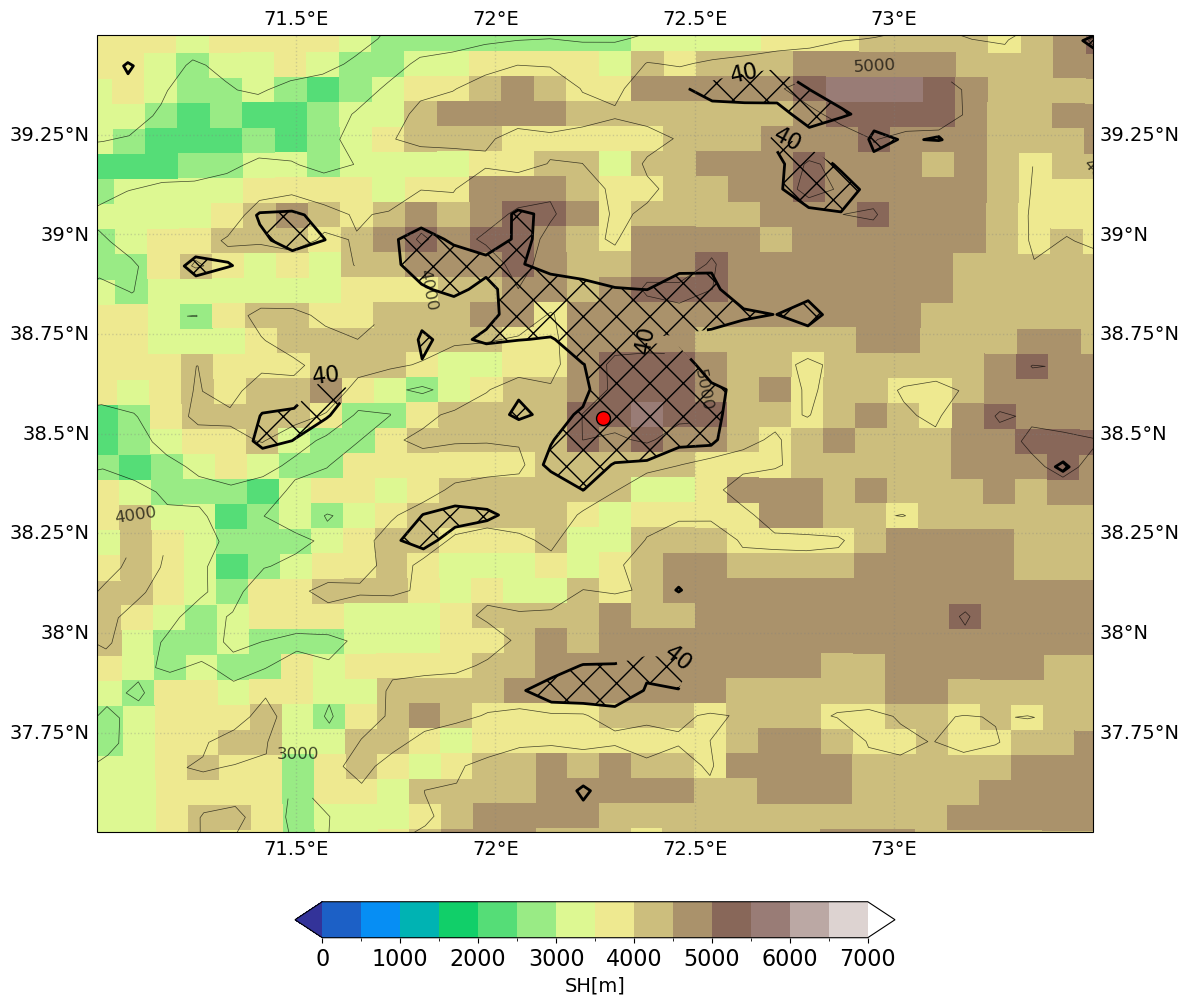

In [13]:
ice_level=40# % of ice on grid cell

clevs=np.arange(0,7500,500)
cmap_mod = plt.get_cmap('terrain')
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap_mod.N, extend="both")

fig, ax = plt.subplots(figsize=(12, 12),
                         subplot_kw={'projection': ccrs.PlateCarree()})


im = ax.pcolormesh(ds_lon, ds_lat, ds_SH,
                       transform=ccrs.PlateCarree(), cmap=cmap_mod,norm=norm,shading='auto')
# ax.add_feature(cfeature.COASTLINE)
# ax.add_feature(cfeature.BORDERS, linestyle=':')

ICE1=ax.contourf(ds_lon, ds_lat,ds_ICE,
            levels=[10,ice_level,100],
            hatches=['','X','X'],
            colors="none",
            transform=ccrs.PlateCarree())

#    ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', linestyle='--')
ax.set_aspect(1.0)
SH1 = ax.contour(ds_lon, ds_lat, ds_SH,
                             levels=[1000,2000,3000,4000,5000,6000,7000],
                             colors="k", linewidths=0.5, alpha=0.7,
                             transform=ccrs.PlateCarree())
ax.clabel(SH1, inline=True, fontsize=12, fmt="%d")
    
ICE2= ax.contour(ds_lon, ds_lat, ds_ICE,
                    levels=[ice_level],
                    colors="black", linewidths=2.0, alpha=1.0,
                    transform=ccrs.PlateCarree())

ax.clabel(ICE2, inline=True, fontsize=16, fmt="%d")
 
ax.set_extent([71, 73.5, 37.5, 39.5], crs=ccrs.PlateCarree())

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=1, color="gray", alpha=0.3, linestyle=":")
gl.xlabel_style = {"size": 14}
gl.ylabel_style = {"size": 14}

  
cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.03])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal")
cbar.set_label(f"{'SH'}[{'m'}]", fontsize=14)
cbar.ax.tick_params(labelsize=16)

fig.subplots_adjust(left=0.2, right=0.8, top=0.95, bottom=0.1, wspace=0.05, hspace=0.2)
plt.tight_layout()

# Jasgulem ice core : red dot
ax.plot(jasg_lon, jasg_lat,
        marker='o', markersize=10,
        markeredgecolor='black', markerfacecolor='red',
        transform=ccrs.PlateCarree())

plt.show()

### MAR datasets

In [14]:
variable='TTZ'

ds_TTZ = xr.open_mfdataset(sourceData_1 + "TTZ_monmean_MARv3.14_ER5_spin2_GRp_*.nc").isel(ZTQLEV=0).TTZ.load()

ds_TTZ = ds_TTZ.assign_coords(X=np.round(ds_TTZ.X.values))
ds_TTZ = ds_TTZ.assign_coords(Y=np.round(ds_TTZ.Y.values))
ds_TTZ = ds_TTZ.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_TTZ = ds_TTZ[:,k:-k,k:-k]

In [15]:
variable='RF'

ds_RF = xr.open_mfdataset(sourceData_1 + "RF_monsum_MARv3.14_ER5_spin2_GRp_*.nc").RF.load()

ds_RF = ds_RF.assign_coords(X=np.round(ds_RF.X.values))
ds_RF = ds_RF.assign_coords(Y=np.round(ds_RF.Y.values))
ds_RF = ds_RF.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_RF = ds_RF[:,k:-k,k:-k]

In [16]:
variable='SF'

ds_SF = xr.open_mfdataset(sourceData_1 + "SF_monsum_MARv3.14_ER5_spin2_GRp_*.nc").SF.load()

ds_SF = ds_SF.assign_coords(X=np.round(ds_SF.X.values))
ds_SF = ds_SF.assign_coords(Y=np.round(ds_SF.Y.values))
ds_SF = ds_SF.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_SF = ds_SF[:,k:-k,k:-k]

In [17]:
variable='ME' 

ds_ME = xr.open_mfdataset(sourceData_1 + "ME_monsum_MARv3.14_ER5_spin2_GRp_*.nc").ME.isel(SECTOR1_1=0).load()

ds_ME = ds_ME.assign_coords(X=np.round(ds_ME.X.values))
ds_ME = ds_ME.assign_coords(Y=np.round(ds_ME.Y.values))
ds_ME = ds_ME.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_ME = ds_ME[:,k:-k,k:-k]
ds_ME = - ds_ME

In [18]:
variable='SMB' 
#"Surface Mass Balance (SMB~SF+RF-RU-SU-SW)" 

ds_SMB = xr.open_mfdataset(sourceData_1 + "SMB_monsum_MARv3.14_ER5_spin2_GRp_*.nc").SMB.isel(SECTOR=0).load()

ds_SMB = ds_SMB.assign_coords(X=np.round(ds_SMB.X.values))
ds_SMB = ds_SMB.assign_coords(Y=np.round(ds_SMB.Y.values))
ds_SMB = ds_SMB.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_SMB = ds_SMB[:,k:-k,k:-k]

In [19]:
variable='SW' 

# MANQUE FICHIER 2025 SW

#"Surface Water"

ds_SW = xr.open_mfdataset(sourceData_1 + "SW_monsum_MARv3.14_ER5_spin2_GRp_*.nc").SW.isel(SECTOR1_1=0).load()

ds_SW = ds_SW.assign_coords(X=np.round(ds_SW.X.values))
ds_SW = ds_SW.assign_coords(Y=np.round(ds_SW.Y.values))
ds_SW = ds_SW.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_SW = ds_SW[:,k:-k,k:-k]

In [20]:
variable='RU' 
# Run Off

ds_RU = xr.open_mfdataset(sourceData_1 + "RU_monsum_MARv3.14_ER5_spin2_GRp_*.nc").RU.isel(SECTOR=0).load()

ds_RU = ds_RU.assign_coords(X=np.round(ds_RU.X.values))
ds_RU = ds_RU.assign_coords(Y=np.round(ds_RU.Y.values))
ds_RU = ds_RU.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_RU = ds_RU[:,k:-k,k:-k]

In [21]:
variable='RZ' 
# Refreezing // il faut un monSUM pour RW

ds_RZ = xr.open_mfdataset(sourceData_1 + "RZ_monsum_MARv3.14_ER5_spin2_GRp_*.nc").RZ.isel(SECTOR1_1=0).load()

ds_RZ = ds_RZ.assign_coords(X=np.round(ds_RZ.X.values))
ds_RZ = ds_RZ.assign_coords(Y=np.round(ds_RZ.Y.values))
ds_RZ = ds_RZ.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_RZ = ds_RZ[:,k:-k,k:-k]

In [22]:
variable='SU' 
# SMB = SF - ME +RZ - SU - SW

ds_SU = -(ds_SF - (-ds_ME) + ds_RZ - ds_SW - ds_SMB)

In [23]:
variable='SU' 
# SMB = SF + RF - RU - SU - SW

ds_SU_2 = -(ds_SF + ds_RF -ds_RU - ds_SW - ds_SMB)

In [24]:
##Fedchenko Accumulation basin

mask_Fed = (
    (ds_lon >= 72.25) & (ds_lon <= 72.5) &
    (ds_lat >= 38.5) & (ds_lat <= 38.7)
)

SH_Fed = ds_SH.where(mask_Fed, drop=True)
lon_Fed = ds_lon.where(mask_Fed, drop=True)
lat_Fed = ds_lat.where(mask_Fed, drop=True)

ds_TTZ_Fed = ds_TTZ.where(mask_Fed, drop=True)
ds_RF_Fed = ds_RF.where(mask_Fed, drop=True)
ds_SF_Fed = ds_SF.where(mask_Fed, drop=True)
# ds_ME_Fed = ds_ME.where(mask_Fed, drop=True)
ds_SMB_Fed = ds_SMB.where(mask_Fed, drop=True)

/tmp/ipykernel_513390/229444792.py:11: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  m = ax.pcolormesh(ds_lon_jasg, ds_lat_jasg, ds_SH_jasg, shading='auto')#,vmin=0, vmax=100)


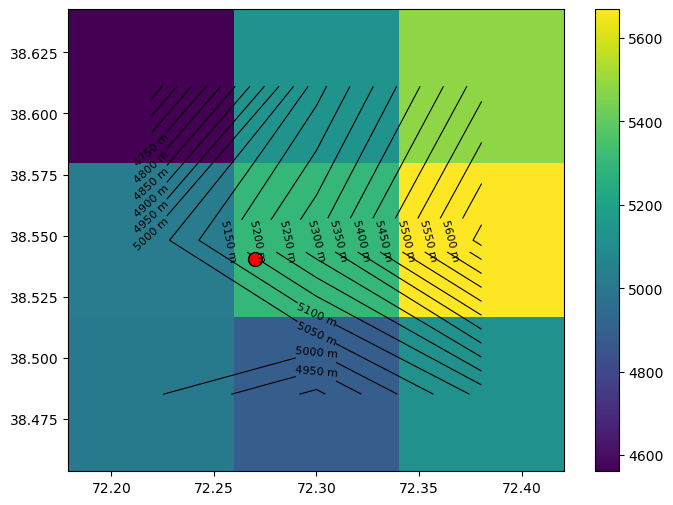

In [25]:
ds_SH_jasg = ds_SH.isel(Y=slice(iY-1, iY+2), X=slice(iX-1, iX+2))
ds_lat_jasg = ds_lat.isel(Y=slice(iY-1, iY+2), X=slice(iX-1, iX+2))
ds_lon_jasg = ds_lon.isel(Y=slice(iY-1, iY+2), X=slice(iX-1, iX+2))

X, Y = np.meshgrid([0,1,2], [0,1,2])

levels = np.arange(3000, 6500, 50)  

fig, ax = plt.subplots(figsize=(8,6))

m = ax.pcolormesh(ds_lon_jasg, ds_lat_jasg, ds_SH_jasg, shading='auto')#,vmin=0, vmax=100)                   
contours = ax.contour(ds_lon_jasg, ds_lat_jasg, ds_SH_jasg, levels=levels, colors='black', linewidths=0.8)

ax.clabel(contours, inline=True, fontsize=8, fmt='%d m')         


cbar = fig.colorbar(m, ax=ax, orientation='vertical')
# cbar.set_label("Ice mask")

# Jasgulem ice core
ax.plot(jasg_lon, jasg_lat,
        marker='o', markersize=10,
        markeredgecolor='black', markerfacecolor='red')
        # transform=ccrs.PlateCarree())

plt.show()

## LOAD HARv2 dataset

In [26]:
# from : https://github.com/msantolariaotin/MAR-RECAP/blob/main/scripts/comparison_pr.crhips_HARv2_MAR_Fedchendko_allseasons.ipynb
# Variable :  pr

fileName7='HARv2_mon_d10km_d_2d_prcp_1980-2023.nc'
ds7_raw0= xr.open_dataset(sourceData_3+'/'+fileName7)['prcp']
ds7_raw=ds7_raw0*24 #mm/h
# Calculate days in each month
days_in_month7= ds7_raw['time'].dt.days_in_month
# Convert to mm/month
ds7= ds7_raw* days_in_month7

def xy_sel_dom(ds,domain):
    latS,latN,lonW,lonE,latlim,lonlim=dom.coord_domain(domain)
    lat_str = ''
    lon_str = ''
    other_dims_str = []
    for dim in ds.coords:
       #print(dim)
        if dim in ['lat', 'latitude','LON']:
            lat_str = dim
        elif dim in ['lon', 'longitude','LAT']:
            lon_str = dim
        else:
            other_dims_str.append(dim)
    mask = (
        (latS < ds[lat_str]) & ( ds[lat_str] < latN) 
    & (lonW < ds[lon_str]) & ( ds[lon_str] < lonE)
    )
    field_dom=ds.where(mask,drop=True)
    return field_dom

pr_harv2=xy_sel_dom(ds7.sel(time=slice(str(iyr),str(fyr))),domain)

In [27]:
# Extract pr HARv2 at Jasgulem drilling site
#HARv2 resolution = 10x10km
dist = (pr_harv2.lat - jasg_lat)**2 + (pr_harv2.lon - jasg_lon)**2
j, i = np.unravel_index(dist.argmin(), dist.shape)

pr_harv2_jasg = pr_harv2.isel(south_north=j, west_east=i)

/tmp/ipykernel_513390/3258494667.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  j, i = np.unravel_index(dist.argmin(), dist.shape)


## Sorties de MAR au point de Grille JASGULEM ICE CORE

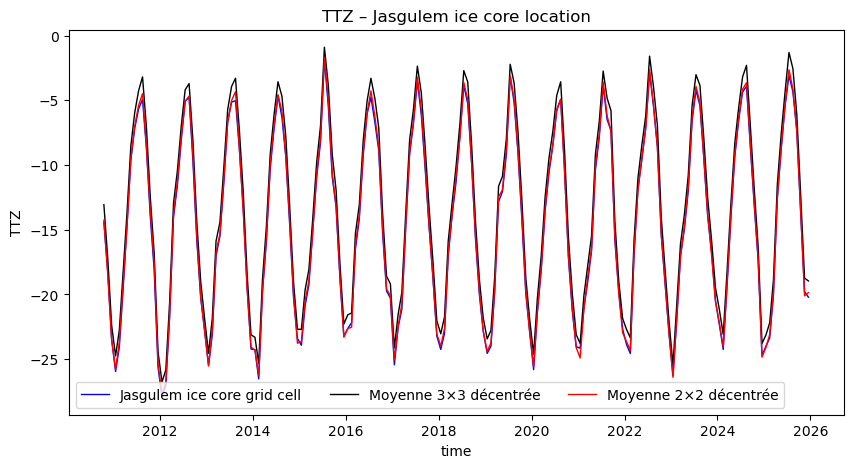

In [28]:
# TTZ at Jasgulem ice core site

plt.figure(figsize=(10,5))

# Plot 9 points individuellement
# for i in range(3):
#     for j in range(3):
#         ds_TTZ.isel(Y=iY-1+i, X=iX-1+j).plot(label=f"Y={iY-1+i}, X={iX-1+j}", alpha=0.5)

ds_TTZ_jasg =  ds_TTZ.isel(Y=iY, X=iX).sel(time=slice("2010-09-30", "2025-12-31"))
ds_TTZ_jasg.plot(label="Jasgulem ice core grid cell", linewidth=1, color="blue")

# ds_TTZ_jasg =  ds_TTZ.isel(Y=iY-1, X=iX)
# ds_TTZ_jasg.plot(label="Jasgulem ice core grid cell", linewidth=1, color="black")
# ds_TTZ_jasg =  ds_TTZ.isel(Y=iY-2, X=iX)
# ds_TTZ_jasg.plot(label="Jasgulem ice core grid cell", linewidth=1, color="purple")

# Moyenne 3×3 grid cells close to drilling site, centrée sur drilling site
ds_TTZ_jasg_mean = ds_TTZ.isel(Y=slice(iY-1, iY+2),
                          X=slice(iX-1, iX+2)).mean(dim=["Y", "X"]).sel(time=slice("2010-09-30", "2025-12-31"))
ds_TTZ_jasg_mean.plot(label="Moyenne 3×3 décentrée", linewidth=1, color="black")

# Moyenne 2×2 grid cells close to drilling site, drilling site au sud-west de la zone considérée
ds_TTZ_jasg_mean = ds_TTZ.isel(Y=slice(iY-1, iY+1),
                          X=slice(iX, iX+2)).mean(dim=["Y", "X"]).sel(time=slice("2010-09-30", "2025-12-31"))
ds_TTZ_jasg_mean.plot(label="Moyenne 2×2 décentrée", linewidth=1, color="red")

# Moyenne 3×3 grid cells close to drilling site, drilling site au sud-west de la zone considérée
# ds_TTZ_jasg_mean = ds_TTZ.isel(Y=slice(iY-2, iY)).mean(dim=["Y", "X"])
# ds_TTZ_jasg_mean.plot(label="Moyenne 3×3 décentrée", linewidth=1, color="orange")

plt.legend(ncol=3)
plt.title("TTZ – Jasgulem ice core location")
plt.ylabel("TTZ")
plt.show()

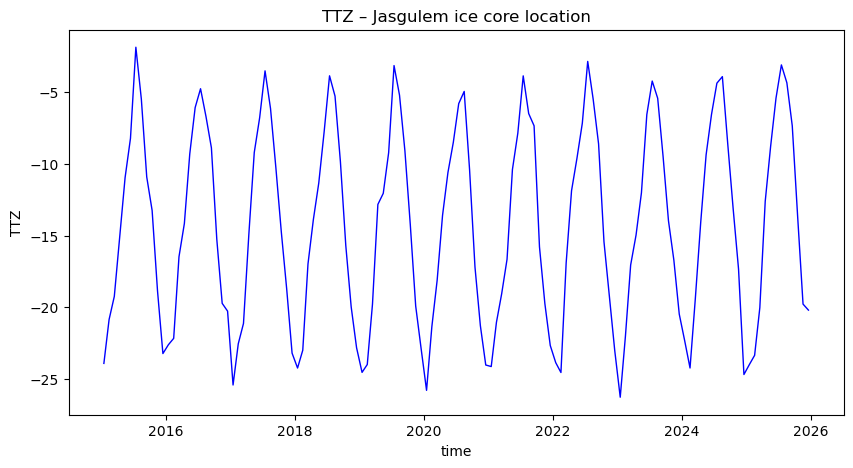

In [29]:
# TTZ at Jasgulem ice core site

plt.figure(figsize=(10,5))

ds_TTZ_jasg =  ds_TTZ.isel(Y=iY, X=iX).sel(time=slice("2015-01-01", "2025-12-31"))
ds_TTZ_jasg.plot(label="Jasgulem ice core grid cell", linewidth=1, color="blue")

#plt.legend(ncol=3)
plt.title("TTZ – Jasgulem ice core location")
plt.ylabel("TTZ")
plt.show()

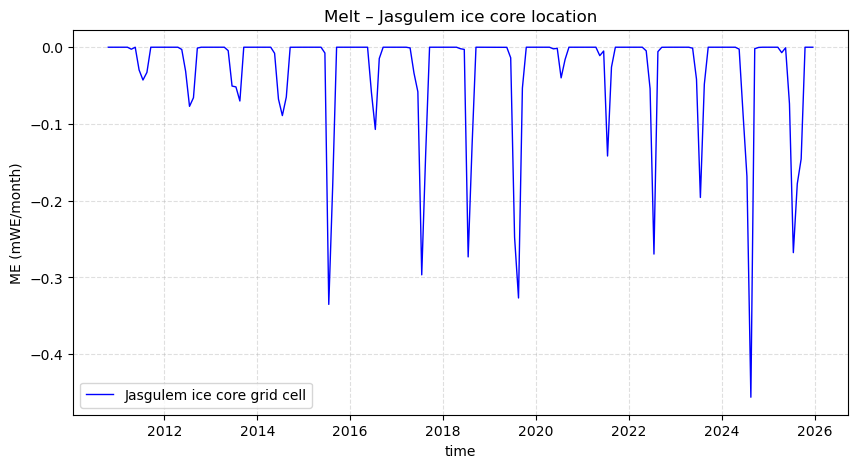

In [30]:
# ME at Jasgulem ice core site

plt.figure(figsize=(10,5))

ds_ME_jasg =  ds_ME.isel(Y=iY, X=iX).sel(time=slice("2010-09-30", "2025-12-31"))/1000
ds_ME_jasg.plot(label="Jasgulem ice core grid cell", linewidth=1, color="blue")

plt.legend(ncol=3)
plt.title("Melt – Jasgulem ice core location")
plt.ylabel("ME (mWE/month)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

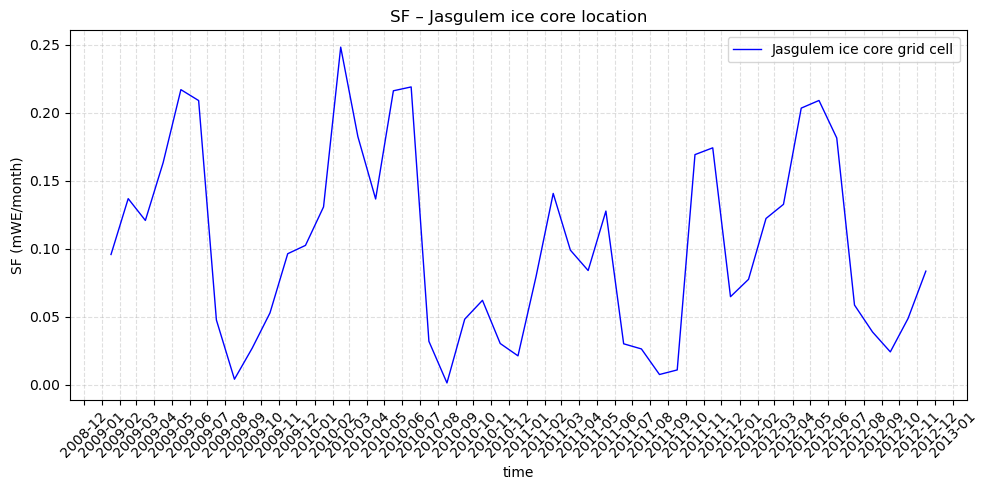

In [31]:
# SF at Jasgulem ice core site
plt.figure(figsize=(10,5))

ds_SF_jasg = ds_SF.isel(Y=iY, X=iX).sel(time=slice("2009-01-01", "2012-12-01")) / 1000
ds_SF_jasg.plot(label="Jasgulem ice core grid cell", linewidth=1, color="blue")

#Ticks mensuels
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))   # un tick par mois
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  # format lisible

#Grille verticale alignée sur les ticks
ax.grid(True, which='major', axis='x', linestyle='--', alpha=0.4)

plt.legend(ncol=3)
plt.title("SF – Jasgulem ice core location")
plt.ylabel("SF (mWE/month)")

# optionnel : rotation pour lisibilité
plt.xticks(rotation=45)

plt.grid(True, linestyle="--", alpha=0.4)  # garde aussi la grille horizontale
plt.tight_layout()
plt.show()

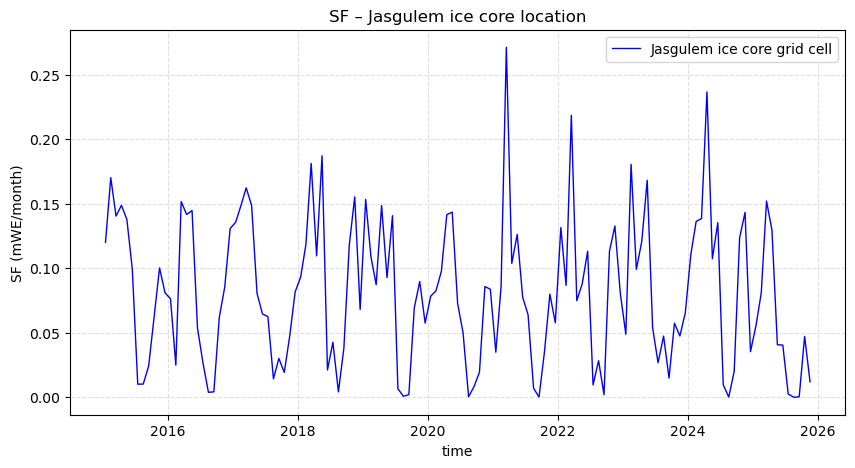

In [32]:
# SF at Jasgulem ice core site

plt.figure(figsize=(10,5))

ds_SF_jasg =  ds_SF.isel(Y=iY, X=iX).sel(time=slice("2015-01-01", "2025-12-01"))/1000
ds_SF_jasg.plot(label="Jasgulem ice core grid cell", linewidth=1, color="blue")

plt.legend(ncol=3)
plt.title("SF – Jasgulem ice core location")
plt.ylabel("SF (mWE/month)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-AUG' is deprecated and will be removed in a future version, please use 'YE-AUG' instead.
  self.index_grouper = pd.Grouper(


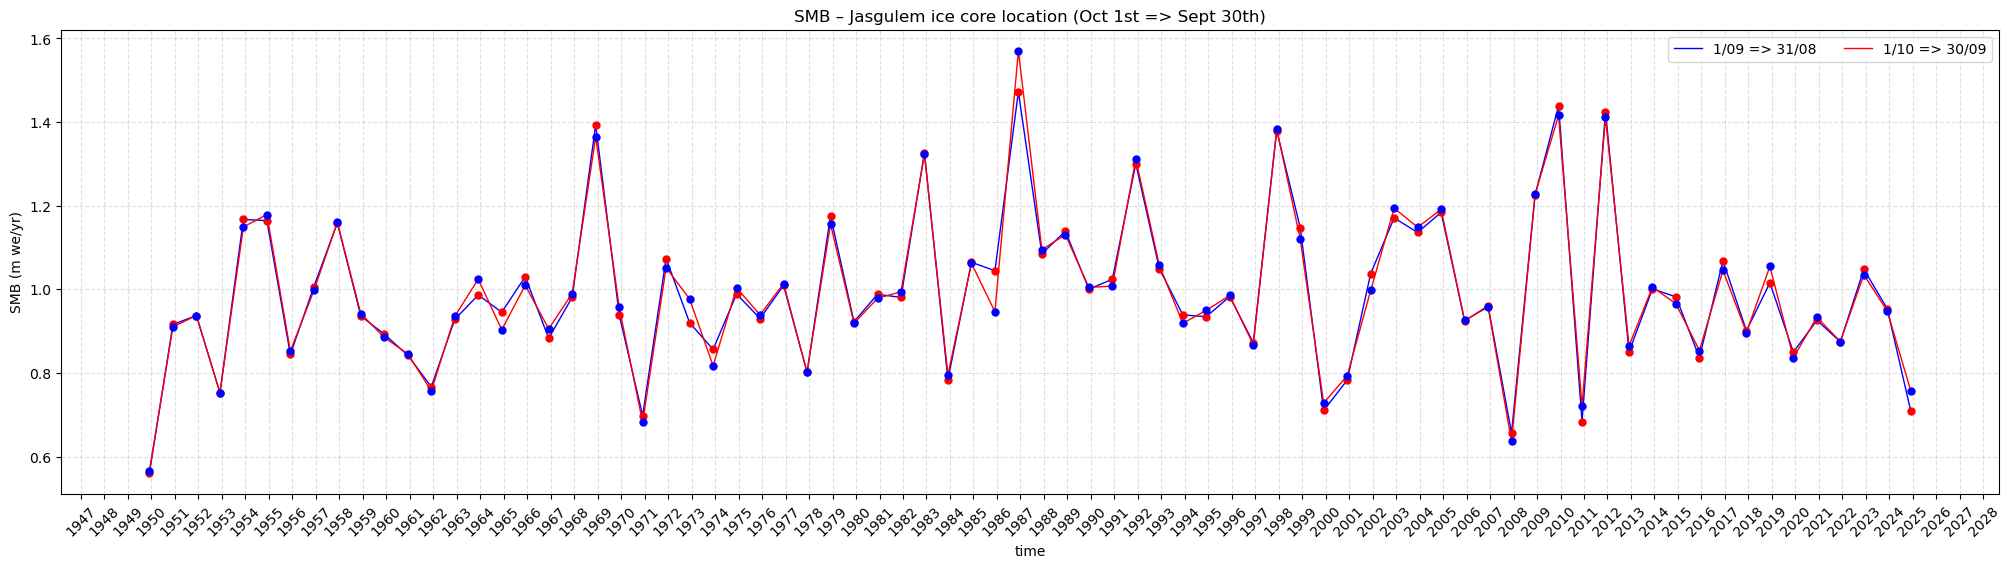

In [33]:
#SMB Annual

plt.figure(figsize=(25,8))

# Point précis Jasgulem
ds_jasg = ds_SMB.isel(Y=iY, X=iX)

ds_jasg_sep = ds_jasg.resample(time="A-SEP").sum().sel(time=slice("1950-09-30", "2025-10-01"))/1000
ds_jasg_sep['time'] = (ds_jasg_sep['time'].values.astype('datetime64[M]') - np.timedelta64(9, 'M')).astype('datetime64[ns]') #plot yr 2014-2015 on 1/1/2015 similar to Lambrecht

ds_jasg_aug = ds_jasg.resample(time="A-AUG").sum().sel(time=slice("1950-08-31", "2025-09-01"))/1000
ds_jasg_aug['time'] = (ds_jasg_aug['time'].values.astype('datetime64[M]') - np.timedelta64(8, 'M')).astype('datetime64[ns]') #plot yr 2014-2015 on 1/1/2015 similar to Lambrecht

ds_jasg_sep.plot(label="1/09 => 31/08", linewidth=1, color="blue")
ds_jasg_aug.plot(label="1/10 => 30/09", linewidth=1, color="red")

plt.plot(ds_jasg_sep.time,
         ds_jasg_sep,
         'o', color='red', markersize=5)

plt.plot(ds_jasg_aug.time,
         ds_jasg_aug,
         'o', color='blue', markersize=5)

# # Moyenne 3×3 centrée
# ds_SMB_jasg_mean = ds_SMB.isel(Y=slice(iY-1, iY+2),
#                                X=slice(iX-1, iX+2)).mean(dim=["Y", "X"])
# ds_SMB_jasg_mean_annual = ds_SMB_jasg_mean.resample(time="A-SEP").sum().sel(time=slice("2010-09-30", "2024-10-01"))/1000
# ds_SMB_jasg_mean_annual['time'] = (ds_SMB_jasg_mean_annual['time'].values.astype('datetime64[M]') - np.timedelta64(9, 'M')).astype('datetime64[ns]') #plot yr 2014-2015 on 1/1/2015 similar to Lambrecht

# ds_SMB_jasg_mean_annual.plot(label="mean 3×3 grid cells", linewidth=1, color="black")

# # Moyenne 2×2 décentrée
# ds_SMB_jasg_mean = ds_SMB.isel(Y=slice(iY-1, iY+1),
#                                X=slice(iX, iX+2)).mean(dim=["Y", "X"])
# ds_SMB_jasg_mean_annual = ds_SMB_jasg_mean.resample(time="A-SEP").sum().sel(time=slice("2010-09-30", "2024-10-01"))/1000
# ds_SMB_jasg_mean_annual['time'] = (ds_SMB_jasg_mean_annual['time'].values.astype('datetime64[M]') - np.timedelta64(9, 'M')).astype('datetime64[ns]') #plot yr 2014-2015 on 1/1/2015 similar to Lambrecht

# ds_SMB_jasg_mean_annual.plot(label="mean 2×2 grid cells décentré", linewidth=1, color="green")

# # # Moyenne 3×3 décentrée
# # ds_SMB_jasg_mean = ds_SMB.isel(Y=slice(iY-2, iY+1),
# #                                X=slice(iX, iX+3)).mean(dim=["Y", "X"])
# # ds_SMB_jasg_mean_annual = ds_SMB_jasg_mean.resample(time="A-SEP").sum().sel(time=slice("2010-09-30", "2024-10-01"))/1000
# # ds_SMB_jasg_mean_annual.plot(label="mean 3×3 grid cells décentré", linewidth=1, color="red")


# # maille plus haute que Jasgulem
# ds_SMB_jasg_mean = ds_SMB.isel(Y=iY,X=iX+1)
# ds_SMB_jasg_mean_annual = ds_SMB_jasg_mean.resample(time="A-SEP").sum().sel(time=slice("2010-09-30", "2024-10-01"))/1000
# ds_SMB_jasg_mean_annual['time'] = (ds_SMB_jasg_mean_annual['time'].values.astype('datetime64[M]') - np.timedelta64(9, 'M')).astype('datetime64[ns]') #plot yr 2014-2015 on 1/1/2015 similar to Lambrecht

# ds_SMB_jasg_mean_annual.plot(label="Single cell - Summit East of drilling", linewidth=1, color="red")

# # maille #2 plus haute que Jasgulem
# ds_SMB_jasg_mean = ds_SMB.isel(Y=iY-1,X=iX+1)
# ds_SMB_jasg_mean_annual = ds_SMB_jasg_mean.resample(time="A-SEP").sum().sel(time=slice("2010-09-30", "2024-10-01"))/1000
# ds_SMB_jasg_mean_annual['time'] = (ds_SMB_jasg_mean_annual['time'].values.astype('datetime64[M]') - np.timedelta64(9, 'M')).astype('datetime64[ns]') #plot yr 2014-2015 on 1/1/2015 similar to Lambrecht

# ds_SMB_jasg_mean_annual.plot(label="Single Celle - high glacier, north East of drilling", linewidth=1, color="purple")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

# Ajustement des marges pour éviter le chevauchement
plt.subplots_adjust(bottom=0.3)  # Plus d'espace en bas

plt.legend(ncol=3)
plt.title("SMB – Jasgulem ice core location (Oct 1st => Sept 30th)")
plt.ylabel("SMB (m we/yr)")

plt.grid(True, linestyle="--", alpha=0.4)

plt.savefig("FIG_smb.png", dpi=300, bbox_inches="tight")

plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-AUG' is deprecated and will be removed in a future version, please use 'YE-AUG' instead.
  self.index_grouper = pd.Grouper(


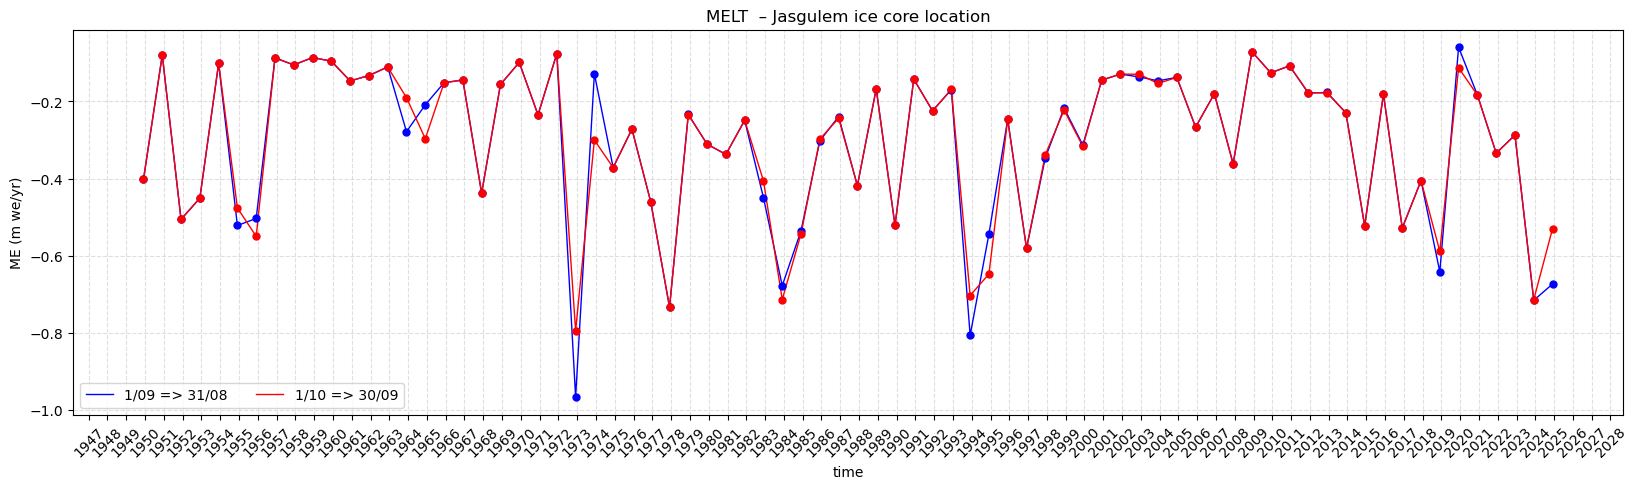

In [34]:
# resample(time="AS-SEP") : aggrege sur une années qui se termine en SEPT. Associa un time qui correspond à la fin de l'année aggrégée
# pour comparer avec Lambrecht, il faut revenir de sept de l'année affichée, à janvier de cette meme année


#MELT Annual 

plt.figure(figsize=(20,5))

# Point précis Jasgulem
ds_jasg = ds_ME.isel(Y=iY, X=iX)

ds_jasg_sep = ds_jasg.resample(time="A-SEP").sum().sel(time=slice("1950-09-30", "2025-10-01"))/1000
ds_jasg_sep['time'] = (ds_jasg_sep['time'].values.astype('datetime64[M]') - np.timedelta64(9, 'M')).astype('datetime64[ns]') #plot yr 2014-2015 on 1/1/2015 similar to Lambrecht

ds_jasg_aug = ds_jasg.resample(time="A-AUG").sum().sel(time=slice("1950-08-31", "2025-09-01"))/1000
ds_jasg_aug['time'] = (ds_jasg_aug['time'].values.astype('datetime64[M]') - np.timedelta64(8, 'M')).astype('datetime64[ns]') #plot yr 2014-2015 on 1/1/2015 similar to Lambrecht

ds_jasg_sep.plot(label="1/09 => 31/08", linewidth=1, color="blue")
ds_jasg_aug.plot(label="1/10 => 30/09", linewidth=1, color="red")

plt.plot(ds_jasg_sep.time,
         ds_jasg_sep,
         'o', color='blue', markersize=5)

plt.plot(ds_jasg_aug.time,
         ds_jasg_aug,
         'o', color='red', markersize=5)


ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.legend(ncol=3)
plt.title("MELT  – Jasgulem ice core location")
plt.ylabel("ME (m we/yr)")

plt.savefig("FIG_smb.png", dpi=300, bbox_inches="tight")

plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-AUG' is deprecated and will be removed in a future version, please use 'YE-AUG' instead.
  self.index_grouper = pd.Grouper(


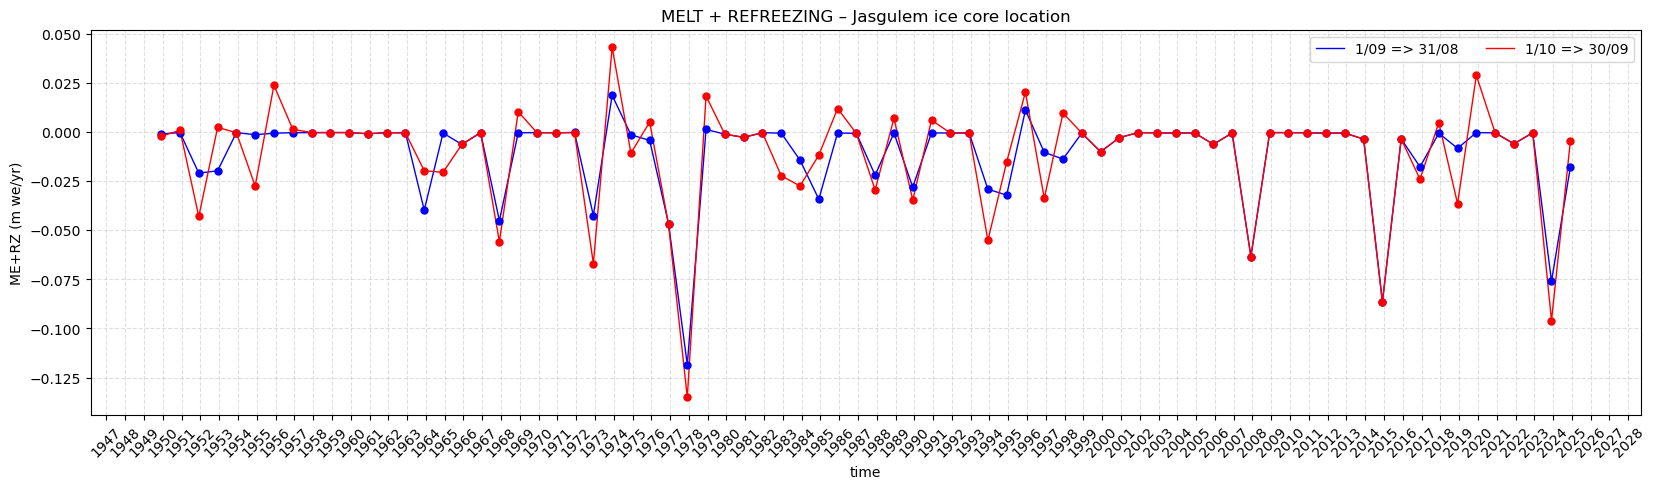

In [42]:
# resample(time="AS-SEP") : aggrege sur une années qui se termine en SEPT. Associa un time qui correspond à la fin de l'année aggrégée
# pour comparer avec Lambrecht, il faut revenir de sept de l'année affichée, à janvier de cette meme année


#MELT Annual 

plt.figure(figsize=(20,5))

# Point précis Jasgulem
ds_jasg = ds_ME.isel(Y=iY, X=iX) + ds_RZ.isel(Y=iY, X=iX)

ds_jasg_sep = ds_jasg.resample(time="A-SEP").sum().sel(time=slice("1950-09-30", "2025-10-01"))/1000
ds_jasg_sep['time'] = (ds_jasg_sep['time'].values.astype('datetime64[M]') - np.timedelta64(9, 'M')).astype('datetime64[ns]') #plot yr 2014-2015 on 1/1/2015 similar to Lambrecht

ds_jasg_aug = ds_jasg.resample(time="A-AUG").sum().sel(time=slice("1950-08-31", "2025-09-01"))/1000
ds_jasg_aug['time'] = (ds_jasg_aug['time'].values.astype('datetime64[M]') - np.timedelta64(8, 'M')).astype('datetime64[ns]') #plot yr 2014-2015 on 1/1/2015 similar to Lambrecht

ds_jasg_sep.plot(label="1/09 => 31/08", linewidth=1, color="blue")
ds_jasg_aug.plot(label="1/10 => 30/09", linewidth=1, color="red")

plt.plot(ds_jasg_sep.time,
         ds_jasg_sep,
         'o', color='blue', markersize=5)

plt.plot(ds_jasg_aug.time,
         ds_jasg_aug,
         'o', color='red', markersize=5)


ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.legend(ncol=3)
plt.title("MELT + REFREEZING – Jasgulem ice core location")
plt.ylabel("ME+RZ (m we/yr)")

plt.savefig("FIG_smb.png", dpi=300, bbox_inches="tight")

plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(


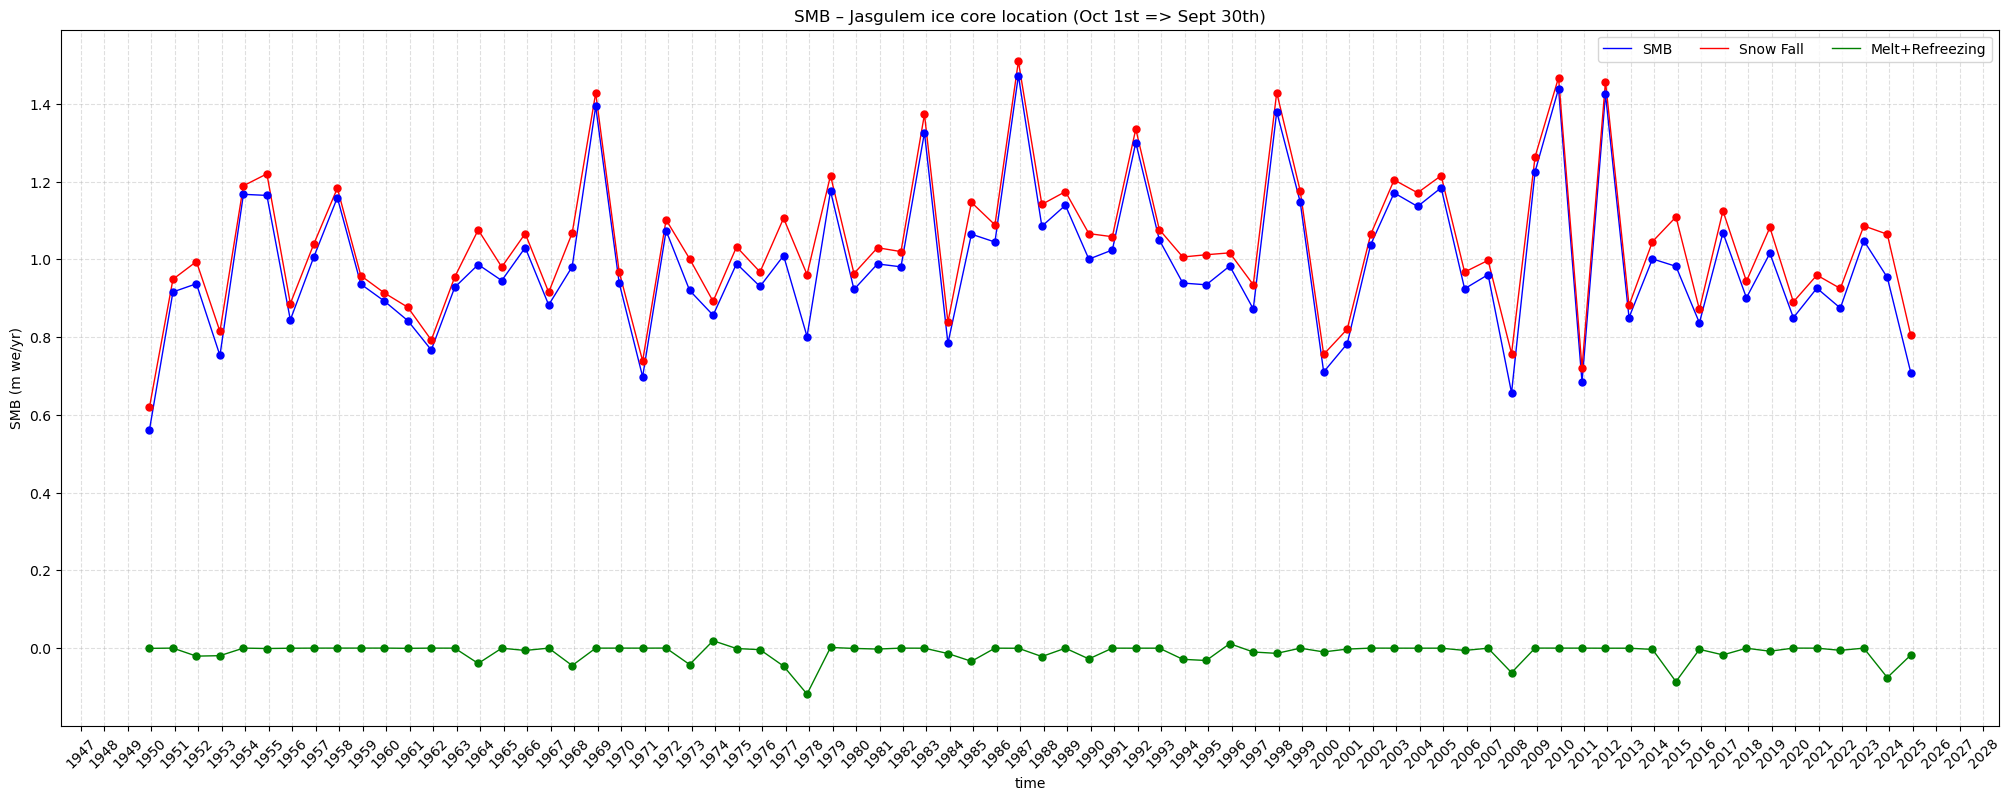

In [43]:
plt.figure(figsize=(25,12))

# Point précis Jasgulem
ds_SMB_jasg = ds_SMB.isel(Y=iY, X=iX)
ds_SMB_jasg_annual = ds_SMB_jasg.resample(time="A-SEP").sum().sel(time=slice("1950-09-30", "2025-10-01"))/1000
ds_SMB_jasg_annual['time'] = (ds_SMB_jasg_annual['time'].values.astype('datetime64[M]') - np.timedelta64(9, 'M')).astype('datetime64[ns]') #plot yr 2014-2015 on 1/1/2015 similar to Lambrecht
ds_SMB_jasg_annual.plot(label="SMB", linewidth=1, color="blue")

ds_SF_jasg = ds_SF.isel(Y=iY, X=iX)
ds_SF_jasg_annual = ds_SF_jasg.resample(time="A-SEP").sum().sel(time=slice("1950-09-30", "2025-10-01"))/1000
ds_SF_jasg_annual['time'] = (ds_SF_jasg_annual['time'].values.astype('datetime64[M]') - np.timedelta64(9, 'M')).astype('datetime64[ns]') #plot yr 2014-2015 on 1/1/2015 similar to Lambrecht
ds_SF_jasg_annual.plot(label="Snow Fall", linewidth=1, color="red")

ds_MERZ_jasg = ds_ME.isel(Y=iY, X=iX) + ds_RZ.isel(Y=iY, X=iX)
ds_MERZ_jasg_annual = ds_MERZ_jasg.resample(time="A-SEP").sum().sel(time=slice("1950-09-30", "2025-10-01"))/1000
ds_MERZ_jasg_annual['time'] = (ds_MERZ_jasg_annual['time'].values.astype('datetime64[M]') - np.timedelta64(9, 'M')).astype('datetime64[ns]') #plot yr 2014-2015 on 1/1/2015 similar to Lambrecht
ds_MERZ_jasg_annual.plot(label="Melt+Refreezing", linewidth=1, color="green")


plt.plot(ds_SMB_jasg_annual.time,
         ds_SMB_jasg_annual,
         'o', color='blue', markersize=5)

plt.plot(ds_SF_jasg_annual.time,
         ds_SF_jasg_annual,
         'o', color='red', markersize=5)

plt.plot(ds_MERZ_jasg_annual.time,
         ds_MERZ_jasg_annual,
         'o', color='green', markersize=5)

ax = plt.gca()

ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

# Ajustement des marges pour éviter le chevauchement
plt.subplots_adjust(bottom=0.3)  # Plus d'espace en bas

plt.legend(ncol=3)
plt.title("SMB – Jasgulem ice core location (Oct 1st => Sept 30th)")
plt.ylabel("SMB (m we/yr)")

plt.grid(True, linestyle="--", alpha=0.4)

plt.savefig("FIG_smb.png", dpi=300, bbox_inches="tight")

plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(


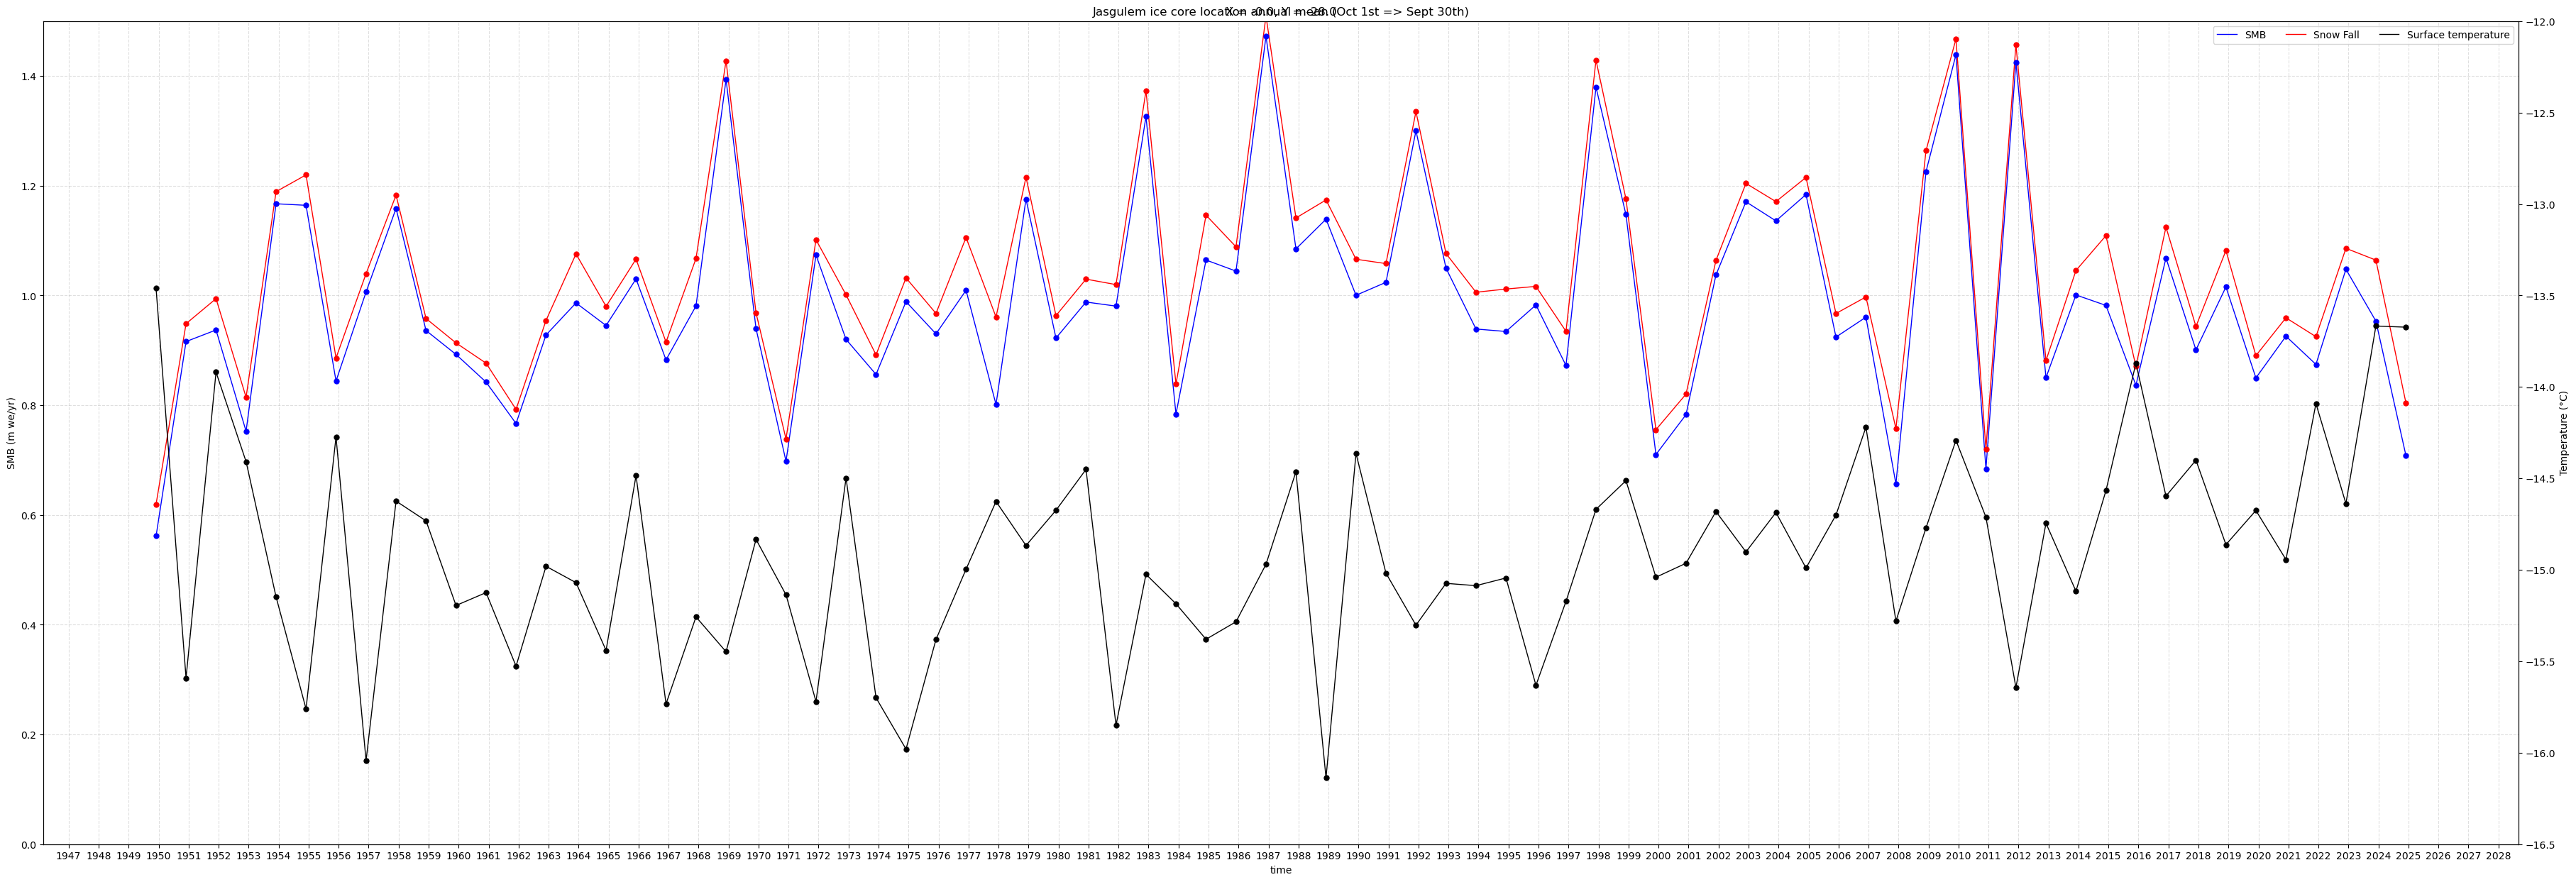

In [35]:
plt.figure(figsize=(45,20))

# Axe principal
ax = plt.gca()
ax2 = ax.twinx()  # axe Y à droite

# --- SMB ---
ds_SMB_jasg = ds_SMB.isel(Y=iY, X=iX)
ds_SMB_jasg_annual = ds_SMB_jasg.resample(time="A-SEP").sum().sel(time=slice("1950-09-30", "2025-10-01"))/1000
ds_SMB_jasg_annual['time'] = (ds_SMB_jasg_annual['time'].values.astype('datetime64[M]') - np.timedelta64(9, 'M')).astype('datetime64[ns]')
ds_SMB_jasg_annual.plot(ax=ax, label="SMB", linewidth=1, color="blue")

# --- SF ---
ds_SF_jasg = ds_SF.isel(Y=iY, X=iX)
ds_SF_jasg_annual = ds_SF_jasg.resample(time="A-SEP").sum().sel(time=slice("1950-09-30", "2025-10-01"))/1000
ds_SF_jasg_annual['time'] = (ds_SF_jasg_annual['time'].values.astype('datetime64[M]') - np.timedelta64(9, 'M')).astype('datetime64[ns]')
ds_SF_jasg_annual.plot(ax=ax, label="Snow Fall", linewidth=1, color="red")

# --- TTZ (axe droit) ---
ds_TTZ_jasg = ds_TTZ.isel(Y=iY, X=iX)
ds_TTZ_jasg_annual = ds_TTZ_jasg.resample(time="A-SEP").mean().sel(time=slice("1950-09-30", "2025-10-01"))
ds_TTZ_jasg_annual['time'] = (ds_TTZ_jasg_annual['time'].values.astype('datetime64[M]') - np.timedelta64(9, 'M')).astype('datetime64[ns]')
ds_TTZ_jasg_annual.plot(
    ax=ax2,
    label="Surface temperature",
    linewidth=1,
    color="black"
)

# --- Points ---
ax.plot(ds_SMB_jasg_annual.time, ds_SMB_jasg_annual, 'o', color='blue', markersize=5)
ax.plot(ds_SF_jasg_annual.time, ds_SF_jasg_annual, 'o', color='red', markersize=5)
ax2.plot(ds_TTZ_jasg_annual.time, ds_TTZ_jasg_annual, 'o', color='black', markersize=5)

# --- Axes ---
ax.set_ylabel("SMB (m we/yr)")
ax2.set_ylabel("Temperature (°C)")

ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

# --- Légende combinée ---
lines_1, labels_1 = ax.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax.legend(lines_1 + lines_2, labels_1 + labels_2, ncol=3)

# --- Mise en forme ---
plt.subplots_adjust(bottom=0.3)
plt.title("Jasgulem ice core location annual mean (Oct 1st => Sept 30th)")
ax.grid(True, linestyle="--", alpha=0.4)
ax.set_ylim(0,1.5)
ax2.set_ylim(-16.5,-12 )

plt.savefig("FIG_smb.png", dpi=300, bbox_inches="tight")
plt.show()

## Composantes du SMB au point de grille du forage 2025

In [36]:
# SMB = SF - ME + RZ - SU - SW

smb_dataset = {
    "SF": ds_SF,
    "ME": ds_ME,  
    "RZ": ds_RZ,
    "SU": ds_SU,
    "SW": ds_SW
}

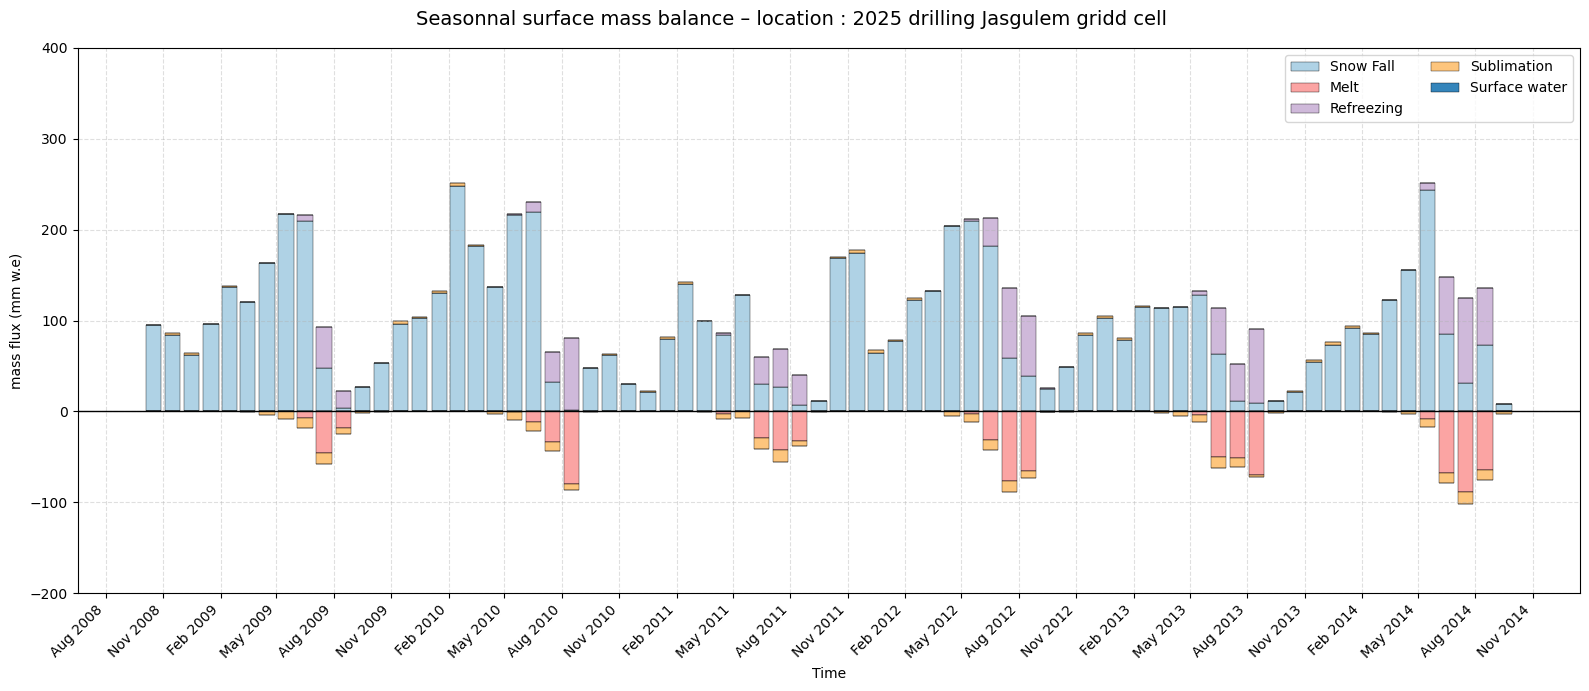

In [37]:
# Vérification avec un autre calcul pour SU => OK!

# SMB = SF + RF - RU - SU - SW

smb_dataset = {
    "SF": ds_SF,
    "ME": ds_ME,  
    "RZ": ds_RZ,
    "SU": ds_SU_2,
    "SW": ds_SW
}

# Période cible
start_date = "2008-10-01"
end_date = "2014-09-30"

# Filtrer les données temporellement
smb_filtered = {}
for key, da in smb_dataset.items():
    smb_filtered[key] = da.sel(time=slice(start_date, end_date))

# Selectionner les données sur la maille ou se trouve le forage Jasgulem 2025
smb_jasg = {}
for key, da in smb_filtered.items():
    smb_jasg[key] = da.isel(Y=iY, X=iX)


# Composantes du SMB
components = ["SF", "ME", "RZ", "SU", "SW"]
labels = {
    "SF": "Snow Fall",
    "ME": "Melt",
    "RZ": "Refreezing",
    "SU": "Sublimation",
    "SW": "Surface water",
}

# Couleurs pour les histos
colors = {
    "SF": "#a6cee3",   # bleu clair 
    "ME": "#fb9a99",   # rouge clair
    "RZ": "#cab2d6",   # violet clair
    "SU": "#fdbf6f",   # orange clair
    "SW": "#1f78b4",   # bleu foncé 
}

# Temps et données
time = smb_jasg[components[0]].time.values
data = np.array([smb_jasg[comp].values for comp in components])

fig, ax = plt.subplots(figsize=(16, 7))

# Initialisation cumul
cumulative_pos = np.zeros_like(data[0])
cumulative_neg = np.zeros_like(data[0])

time_num = mdates.date2num(time)
width = np.median(np.diff(time_num)) * 0.8

for i, comp in enumerate(components):
    values = data[i]

    pos = np.where(values > 0, values, 0)
    neg = np.where(values < 0, values, 0)

    ax.bar(
        time,
        pos,
        width=width,
        bottom=cumulative_pos,
        color=colors[comp],
        label=labels[comp],
        alpha=0.9,
        edgecolor="black",
        linewidth=0.3
    )

    ax.bar(
        time,
        neg,
        width=width,
        bottom=cumulative_neg,
        color=colors[comp],
        alpha=0.9,
        edgecolor="black",
        linewidth=0.3
    )

    cumulative_pos += pos
    cumulative_neg += neg

# Ligne zéro
ax.axhline(0, color='black', linewidth=1)

# Labels
ax.set_ylabel("mass flux (mm w.e)")
ax.set_xlabel("Time")

# Format date
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45, ha="right")
fig.suptitle(f"Seasonnal surface mass balance – location : 2025 drilling Jasgulem gridd cell ", fontsize=14)

ax.legend(frameon=False)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
ax.legend(ncol=2)
ax.set_ylim(-200, 400)


plt.savefig("FIG_smb.png", dpi=300, bbox_inches="tight")

plt.show()

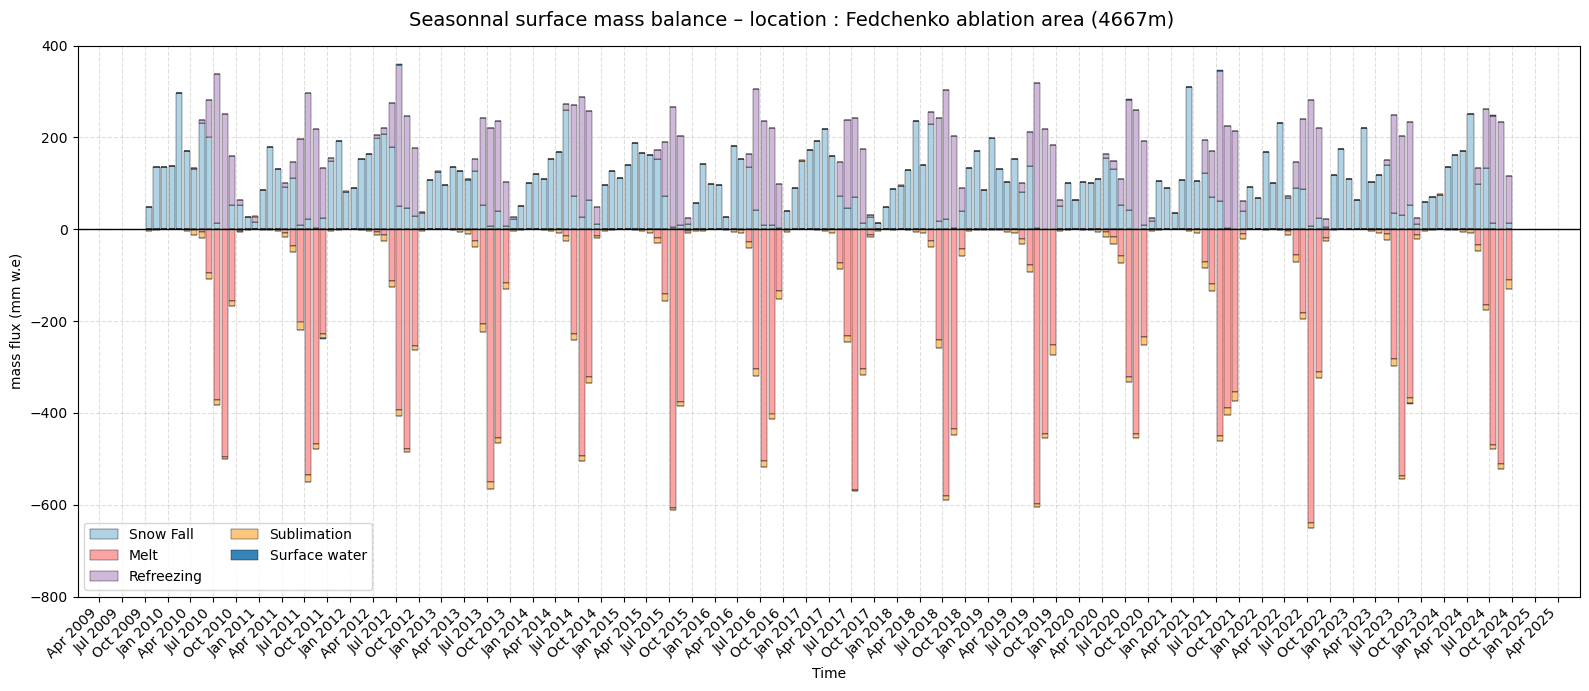

In [38]:
# MANQUE FICHIER 2025 SW


# Vérification avec un autre calcul pour SU => OK!

# SMB = SF + RF - RU - SU - SW

smb_dataset = {
    "SF": ds_SF,
    "ME": ds_ME,  
    "RZ": ds_RZ,
    "SU": ds_SU_2,
    "SW": ds_SW
}

# Période cible
start_date = "2009-10-01"
end_date = "2024-09-30" # MANQUE FICHIER 2025 SW

# Filtrer les données temporellement
smb_filtered = {}
for key, da in smb_dataset.items():
    smb_filtered[key] = da.sel(time=slice(start_date, end_date))

# Selectionner les données sur la maille ou se trouve le forage Jasgulem 2025
smb_jasg = {}
for key, da in smb_filtered.items():
    smb_jasg[key] = da.isel(Y=iY+4, X=iX)


# Composantes du SMB
components = ["SF", "ME", "RZ", "SU", "SW"]
labels = {
    "SF": "Snow Fall",
    "ME": "Melt",
    "RZ": "Refreezing",
    "SU": "Sublimation",
    "SW": "Surface water",
}

# Couleurs pour les histos
colors = {
    "SF": "#a6cee3",   # bleu clair 
    "ME": "#fb9a99",   # rouge clair
    "RZ": "#cab2d6",   # violet clair
    "SU": "#fdbf6f",   # orange clair
    "SW": "#1f78b4",   # bleu foncé 
}

# Temps et données
time = smb_jasg[components[0]].time.values
data = np.array([smb_jasg[comp].values for comp in components])

fig, ax = plt.subplots(figsize=(16, 7))

# Initialisation cumul
cumulative_pos = np.zeros_like(data[0])
cumulative_neg = np.zeros_like(data[0])

time_num = mdates.date2num(time)
width = np.median(np.diff(time_num)) * 0.8

for i, comp in enumerate(components):
    values = data[i]

    pos = np.where(values > 0, values, 0)
    neg = np.where(values < 0, values, 0)

    ax.bar(
        time,
        pos,
        width=width,
        bottom=cumulative_pos,
        color=colors[comp],
        label=labels[comp],
        alpha=0.9,
        edgecolor="black",
        linewidth=0.3
    )

    ax.bar(
        time,
        neg,
        width=width,
        bottom=cumulative_neg,
        color=colors[comp],
        alpha=0.9,
        edgecolor="black",
        linewidth=0.3
    )

    cumulative_pos += pos
    cumulative_neg += neg

# Ligne zéro
ax.axhline(0, color='black', linewidth=1)

# Labels
ax.set_ylabel("mass flux (mm w.e)")
ax.set_xlabel("Time")

# Format date
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45, ha="right")
fig.suptitle(f"Seasonnal surface mass balance – location : Fedchenko ablation area (4667m) ", fontsize=14)

ax.legend(frameon=False)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
ax.legend(ncol=2)
ax.set_ylim(-800, 400)

plt.savefig("FIG_smb.png", dpi=300, bbox_inches="tight")

plt.show()

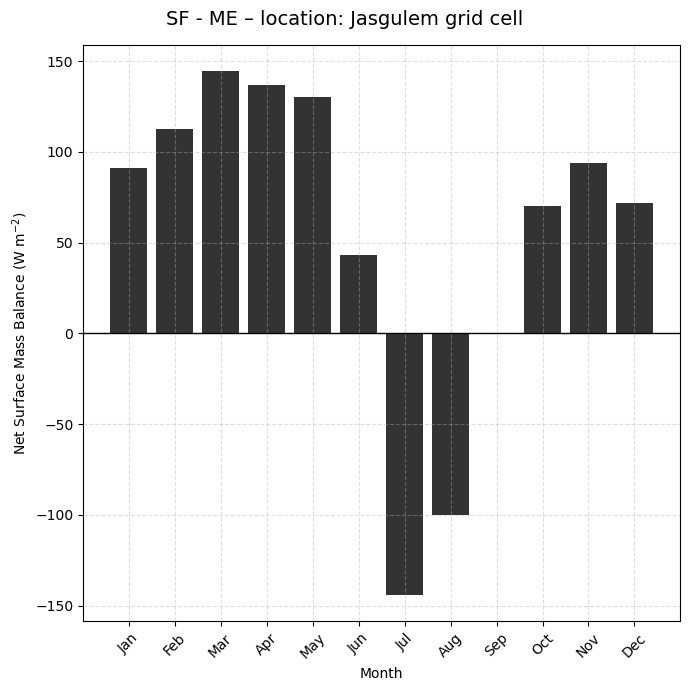

In [39]:
# Période cible
start_date = "2010-10-01"
end_date = "2025-09-30"

# Filtrer les données temporellement
smb_filtered = {}
for key, da in smb_dataset.items():
    smb_filtered[key] = da.sel(time=slice(start_date, end_date))

# Selectionner les données sur la maille ou se trouve le forage Jasgulem 2025
seb_jasg = {}
for key, da in smb_filtered.items():
    smb_jasg[key] = da.isel(Y=iY, X=iX)

# Calcul SEB net
smb_net = (
    smb_jasg["SF"]
    + smb_jasg["ME"]
)

# Climatologie mensuelle
smb_net = smb_net.groupby("time.month").mean()

# Données pour plot
months = np.arange(1, 13)
values = smb_net.values

fig, ax = plt.subplots(figsize=(7, 7))

ax.bar(
    months,
    values,
    width=0.8,
    color="black",
    alpha=0.8
)

ax.axhline(0, color="black", linewidth=1)

ax.set_xticks(months)
ax.set_xticklabels(
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
    rotation=45
)

ax.set_ylabel("Net Surface Mass Balance (W m$^{-2}$)")
ax.set_xlabel("Month")

ax.grid(True, linestyle="--", alpha=0.4)

fig.suptitle("SF - ME – location: Jasgulem grid cell", fontsize=14)

plt.tight_layout()
plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'AS-SEP' is deprecated and will be removed in a future version, please use 'YS-SEP' instead.
  self.index_grouper = pd.Grouper(
/tmp/ipykernel_513390/3580982133.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False)


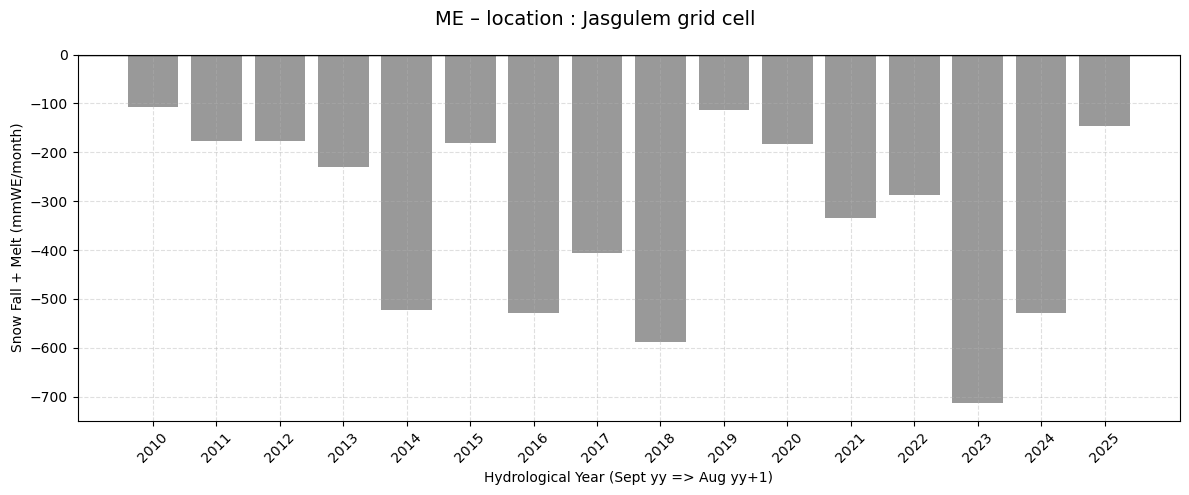

In [40]:
# Période cible
start_date = "2010-10-01"
end_date = "2025-09-30"

# Filtrage temporel
smb_filtered = {
    key: da.sel(time=slice(start_date, end_date))
    for key, da in smb_dataset.items()
}

# extraction pixel
smb_jasg = {
    key: da.isel(Y=iY, X=iX)
    for key, da in smb_filtered.items()
}

# SEB net
smb_net = (
   # smb_jasg["SF"]
     smb_jasg["ME"]

)

# =========================
# AGRÉGATION ANNUELLE (HYDRO YEAR SEP→AUG)
# =========================

smb_yearly = smb_net.resample(time="AS-SEP").sum()

# conversion propre des axes
years = smb_yearly["time.year"].values
values = smb_yearly.values

# =========================
# PLOT
# =========================

fig, ax = plt.subplots(figsize=(12, 5))

pos = np.where(values > 0, values, 0)
neg = np.where(values < 0, values, 0)

ax.bar(years, pos, color="black", alpha=0.8)
ax.bar(years, neg, color="gray", alpha=0.8)

ax.axhline(0, color="black", linewidth=1)

ax.set_ylabel("Snow Fall + Melt (mmWE/month)")
ax.set_xlabel("Hydrological Year (Sept yy => Aug yy+1)")

ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45)

ax.legend(frameon=False)
ax.grid(True, linestyle="--", alpha=0.4)

fig.suptitle("ME – location : Jasgulem grid cell", fontsize=14)

plt.tight_layout()
plt.show()

## Comparison with observations

In [41]:
obs_folder = "/bettik/fainx/MAR_HMA/field_data/pamir/"

obs_file = "field_accu_scenarios.txt"
obs_jog_S2 = 'DataFig7_JOG2020_S2.txt'
obs_jog_S1 = 'DataTable2_JOG2020_S1.txt'
obs_2019_pit = '2019_jasgulem_pit_data.txt'

ds_obs_accu =  np.loadtxt(obs_folder+obs_file, delimiter="\t",skiprows=1)
ds_obs_jog_S2 =  np.loadtxt(obs_folder+obs_jog_S2, delimiter="\t",skiprows=1)
ds_obs_jog_S1 =  np.loadtxt(obs_folder+obs_jog_S1, delimiter="\t",skiprows=1)
ds_obs_2019 = np.loadtxt(obs_folder+obs_2019_pit, delimiter="\t",skiprows=1)

In [42]:
# =========================
# 1. DataFrames OBS
# =========================
accu = pd.DataFrame(ds_obs_accu)
jog_S2  = pd.DataFrame(ds_obs_jog_S2)
jog_S1  = pd.DataFrame(ds_obs_jog_S1)
obs_2019 = pd.DataFrame(ds_obs_2019)

# =========================
# 1. DataFrames REANALYSIS
# =========================
pr_harv2_jasg_annual= pd.DataFrame(pr_harv2_jasg.resample(time="A-AUG").sum().sel(time=slice("2008-09-01", "2023-08-31"))/1000)
pr_harv2_jasg_annual.insert(
    0,
    "year",
    range(2009, 2009 + len(pr_harv2_jasg_annual))
)
pr_harv2_jasg_annual  = pr_harv2_jasg_annual.rename(columns={0: "harv2"})
pr_harv2_jasg_annual = pr_harv2_jasg_annual.sort_values("year", ascending=False).reset_index(drop=True)

# =========================
# 1. DataFrames MODEL
# ========================= SMB
ds_SMB_jasg_annual = pd.DataFrame(ds_SMB.isel(Y=iY, X=iX).resample(time="A-AUG").sum().sel(time=slice("2008-09-01", "2025-08-31")) / 1000)
ds_SMB_jasg_annual.insert(
    0,
    "year",
    range(2009, 2009 + len(ds_SMB_jasg_annual))
)
ds_SMB_jasg_annual  = ds_SMB_jasg_annual.rename(columns={0: "mar_smb"})
ds_SMB_jasg_annual = ds_SMB_jasg_annual.sort_values("year", ascending=False).reset_index(drop=True)

# ========================= SNOW FALL
ds_SF_jasg_annual = pd.DataFrame(ds_SF.isel(Y=iY, X=iX).resample(time="A-AUG").sum().sel(time=slice("2008-09-01", "2025-08-31")) / 1000)
ds_SF_jasg_annual.insert(
    0,
    "year",
    range(2009, 2009 + len(ds_SF_jasg_annual))
)
ds_SF_jasg_annual  = ds_SF_jasg_annual.rename(columns={0: "mar_sf"})
ds_SF_jasg_annual = ds_SF_jasg_annual.sort_values("year", ascending=False).reset_index(drop=True)

# ========================= MELT
ds_ME_jasg_annual = pd.DataFrame(ds_ME.isel(Y=iY, X=iX).resample(time="A-AUG").sum().sel(time=slice("2008-09-01", "2025-08-31")) / 1000)
ds_ME_jasg_annual.insert(
    0,
    "year",
    range(2009, 2009 + len(ds_SMB_jasg_annual))
)
ds_ME_jasg_annual  = ds_ME_jasg_annual.rename(columns={0: "mar_me"})
ds_ME_jasg_annual = ds_ME_jasg_annual.sort_values("year", ascending=False).reset_index(drop=True)

# =========================
# 2. Renommer colonne année
# =========================
accu = accu.rename(columns={0: "year"})
jog_S2  = jog_S2.rename(columns={0: "year"})
jog_S1  = jog_S1.rename(columns={0: "year"})
obs_2019  = obs_2019.rename(columns={0: "year"})

# =========================
# 3. SUPPRESSION des colonnes 1 à 9 de accu: ce sont les depths
# =========================
accu = accu.drop(columns=list(range(2, 10)))
accu = accu.drop(columns=list(range(11, 19)))

# =========================
# 4. Renomer les colonnes 
# =========================
accu = accu.rename(columns={accu.columns[1]: "depth_Fed_2025"})
accu = accu.rename(columns={accu.columns[2]: "accu_Fed_2025"})

#jog.columns  = ["year"] + [f"jog_{i}" for i in range(1, jog.shape[1])]
jog_S2 = jog_S2.rename(columns={jog_S2.columns[1]: "firn_model_2015"})
jog_S2 = jog_S2.rename(columns={jog_S2.columns[2]: "gpr_s2_2015"})
jog_S2 = jog_S2.rename(columns={jog_S2.columns[3]: "harv2_Lambrecht"})
jog_S2 = jog_S2.rename(columns={jog_S2.columns[4]: "S2"})

jog_S1 = jog_S1.rename(columns={jog_S1.columns[1]: "S1"})

obs_2019 = obs_2019.rename(columns={obs_2019.columns[1]: "pit_2019"})

# =========================
# 5. Nettoyage années invalides
# =========================
accu = accu[accu["year"].notna()]
jog_S2  = jog_S2[jog_S2["year"].notna()]
jog_S1  = jog_S1[jog_S1["year"].notna()]
obs_2019  = obs_2019[obs_2019["year"].notna()]
ds_SMB_jasg_annual  = ds_SMB_jasg_annual[ds_SMB_jasg_annual["year"].notna()]

# =========================
# 6. Merge sur year
# =========================
merged = pd.merge(accu, jog_S2, on="year", how="outer")
merged = pd.merge(merged, jog_S1, on="year", how="outer")
merged = pd.merge(merged, obs_2019, on="year", how="outer")
merged = pd.merge(merged, pr_harv2_jasg_annual, on="year", how="outer")
merged = pd.merge(merged, ds_SMB_jasg_annual, on="year", how="outer")
merged = pd.merge(merged, ds_SF_jasg_annual, on="year", how="outer")
merged = pd.merge(merged, ds_ME_jasg_annual, on="year", how="outer")


# =========================
# 7. Tri chronologique
# =========================
merged = merged.sort_values("year", ascending=False).reset_index(drop=True)

# =========================
# 8. garder DataFrame 
# =========================
ds = merged  
ds = ds.dropna(how="all")
ds

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-AUG' is deprecated and will be removed in a future version, please use 'YE-AUG' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-AUG' is deprecated and will be removed in a future version, please use 'YE-AUG' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-AUG' is deprecated and will be removed in a future version, please use 'YE-AUG' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-AUG' is deprecated and will be removed in a future version, please use 'YE-AUG' instead.
  self.index_grouper = pd.Grouper(


,year,depth_Fed_2025,accu_Fed_2025,firn_model_2015,gpr_s2_2015,harv2_Lambrecht,S2,S1,pit_2019,harv2,mar_smb,mar_sf,mar_me
0,2025.0,0.0,2.141993,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.756256,0.823760,-0.529248
1,2024.0,453.0,1.630206,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.947804,1.059190,-0.713462
2,2023.0,771.0,1.335000,NaN,NaN,NaN,NaN,NaN,NaN,2.690328,1.035123,1.073057,-0.287154
3,2022.0,972.0,1.269131,NaN,NaN,NaN,NaN,NaN,NaN,2.339624,0.875122,0.923108,-0.333972
4,2021.0,1178.0,1.068728,NaN,NaN,NaN,NaN,NaN,NaN,2.163827,0.933105,0.967340,-0.183595
5,2020.0,1366.0,0.947912,NaN,NaN,NaN,NaN,NaN,NaN,2.212338,0.836139,0.884065,-0.112785
6,2019.0,1537.0,0.799795,NaN,NaN,NaN,1.41,NaN,0.6,2.727126,1.054667,1.117668,-0.588300
7,2018.0,1673.0,1.871855,NaN,NaN,NaN,NaN,NaN,NaN,2.501698,0.896610,0.935760,-0.405200
8,2017.0,1953.0,1.366651,NaN,NaN,NaN,NaN,NaN,NaN,3.007985,1.045279,1.098650,-0.527983
9,2016.0,2185.0,NaN,NaN,NaN,NaN,NaN,1.301,NaN,2.565352,0.853577,0.890981,-0.180882


In [225]:
df.to_csv("jasgulem_smb.csv", index=False)

In [43]:
ds["harv2_Lambrecht"]/ds["harv2"]

0          NaN
1          NaN
2          NaN
3          NaN
4          NaN
5          NaN
6          NaN
7          NaN
8          NaN
9          NaN
10         NaN
11    0.808011
12    0.778876
13    0.804205
14    0.747585
15    0.824726
16    0.820815
dtype: float64

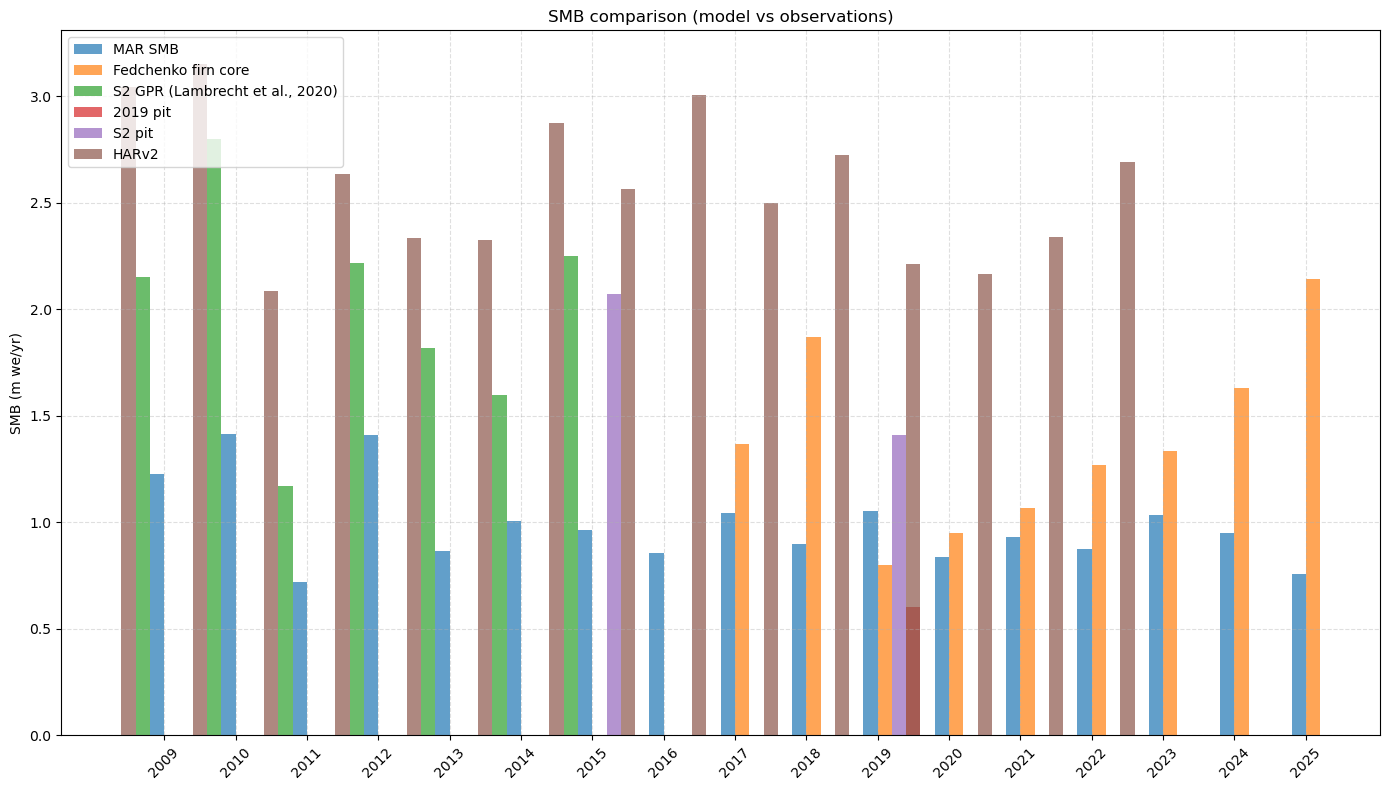

In [44]:
# =========================
# 1. Préparer les données
# =========================
df = ds.copy()

# garder uniquement années utiles (optionnel)
df = df.sort_values("year")

x = np.arange(len(df))
width = 0.2

# =========================
# 2. Plot
# =========================
plt.figure(figsize=(14, 8))

# MAR SMB
plt.bar(x - 0.5*width, df["mar_smb"], width, label="MAR SMB", alpha=0.7)

# Jasgulem obs
plt.bar(x + 0.5*width, df["accu_Fed_2025"], width, label="Fedchenko firn core", alpha=0.7)
plt.bar(x - 1.5*width, df["gpr_s2_2015"], width, label="S2 GPR (Lambrecht et al., 2020)", alpha=0.7)
plt.bar(x + 2.5*width, df["pit_2019"], width, label="2019 pit", alpha=0.7)
plt.bar(x + 1.5*width, df["S2"], width, label="S2 pit", alpha=0.7)

# HARv2
plt.bar(x - 2.5*width, df["harv2"], width, label="HARv2", alpha=0.7)

# =========================
# 3. Axe X
# =========================
labels = df["year"].astype(int).astype(str)
plt.xticks(x, labels, rotation=45)

# =========================
# 4. Mise en forme
# =========================
plt.ylabel("SMB (m we/yr)")
plt.title("SMB comparison (model vs observations)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

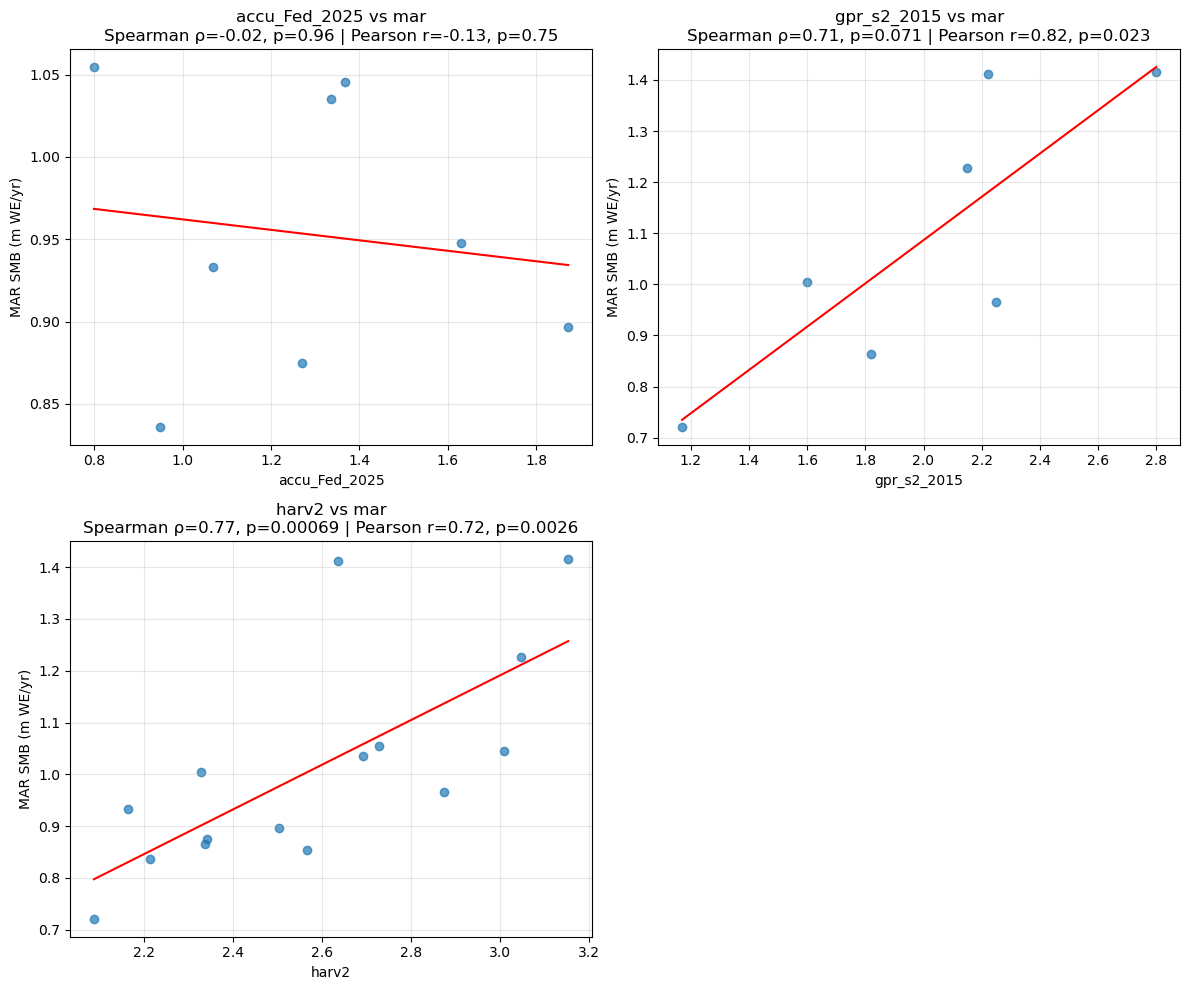

In [228]:
df = ds.copy()

y = df["mar_smb"]

variables = ["accu_Fed_2025", "gpr_s2_2015", "harv2"]

plt.figure(figsize=(12, 10))

results = []

for i, var in enumerate(variables):

    x = df[var]

    # =========================
    # exclusion spécifique
    # =========================
    if var == "accu_Fed_2025":
#        x = x.iloc[1:-1]   # enlève premier + dernier point
        x = x.iloc[1:]   # enlève premier 
        y_tmp = y.iloc[1:-1]
    else:
        y_tmp = y

    # clean NaN
    mask = ~x.isna() & ~y_tmp.isna()
    x_clean = x[mask]
    y_clean = y_tmp[mask]

    if len(x_clean) < 3:
        continue

    # Spearman
    rho, p_spearman = spearmanr(x_clean, y_clean)

    # regression
    res = linregress(x_clean, y_clean)

    results.append({
        "variable": var,
        "r": res.rvalue,
        "r2": res.rvalue**2,
        "pvalue": res.pvalue
    })

    # subplot
    plt.subplot(2, 2, i + 1)

    plt.scatter(x_clean, y_clean, alpha=0.7)

    # regression line
    x_line = np.linspace(x_clean.min(), x_clean.max(), 100)
    y_line = res.intercept + res.slope * x_line
    plt.plot(x_line, y_line, color="red")

    plt.title(
        f"{var} vs mar\n"
        f"Spearman ρ={rho:.2f}, p={p_spearman:.2g} | "
        f"Pearson r={res.rvalue:.2f}, p={res.pvalue:.2g}"
    )

    plt.xlabel(var)
    plt.ylabel("MAR SMB (m WE/yr)")
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

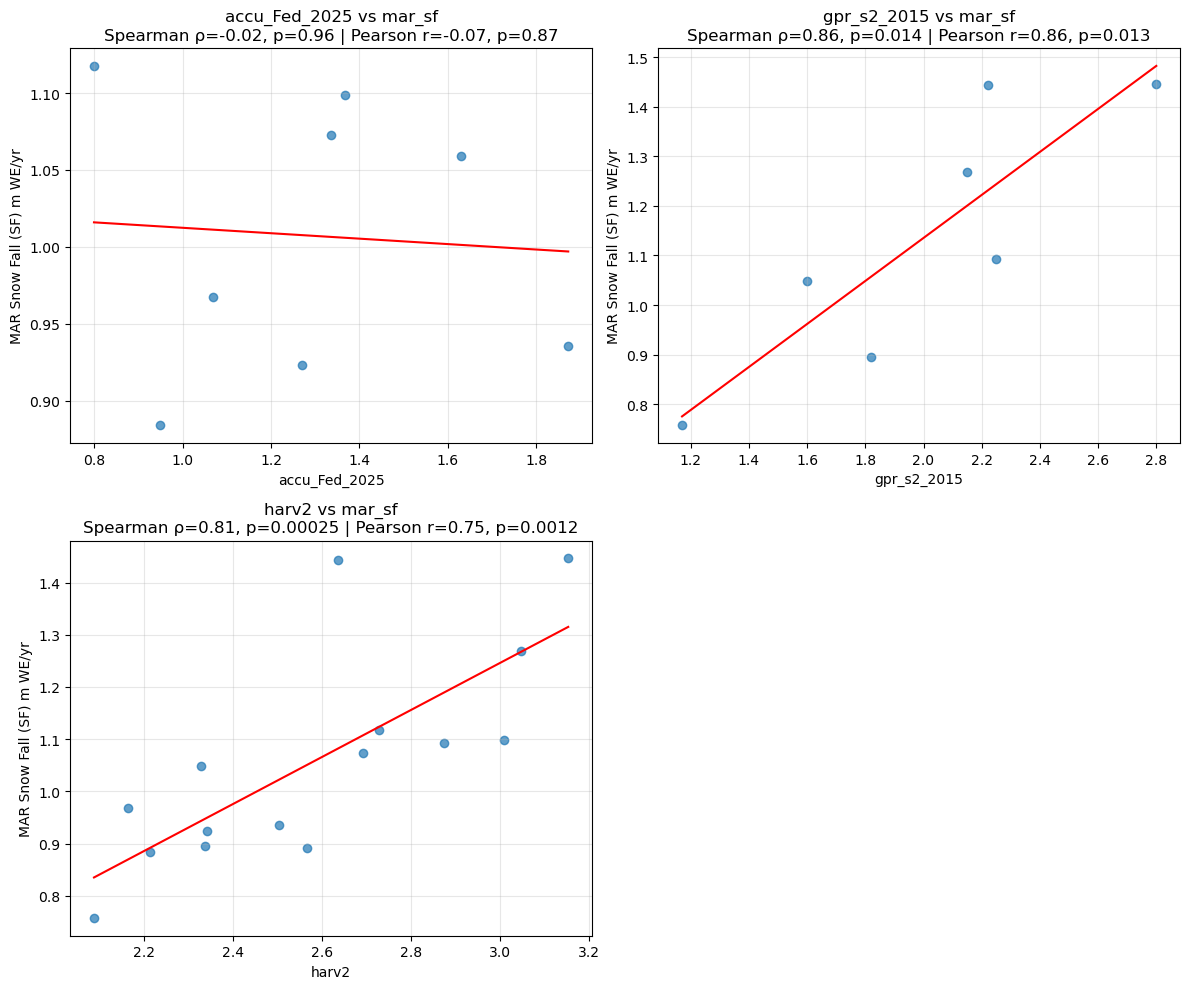

In [229]:
df = ds.copy()

y = df["mar_sf"]

variables = ["accu_Fed_2025", "gpr_s2_2015", "harv2"]

plt.figure(figsize=(12, 10))

results = []

for i, var in enumerate(variables):

    x = df[var]

    # =========================
    # exclusion spécifique
    # =========================
    if var == "accu_Fed_2025":
#        x = x.iloc[1:-1]   # enlève premier + dernier point
        x = x.iloc[1:]   # enlève premier 
        y_tmp = y.iloc[1:-1]
    else:
        y_tmp = y

    # clean NaN
    mask = ~x.isna() & ~y_tmp.isna()
    x_clean = x[mask]
    y_clean = y_tmp[mask]

    if len(x_clean) < 3:
        continue

    # Spearman correlation (rank)
    rho, p_spearman = spearmanr(x_clean, y_clean)

    # regression
    res = linregress(x_clean, y_clean)

    results.append({
        "variable": var,
        "r": res.rvalue,
        "r2": res.rvalue**2,
        "pvalue": res.pvalue
    })

    # subplot
    plt.subplot(2, 2, i + 1)

    plt.scatter(x_clean, y_clean, alpha=0.7)

    # regression line
    x_line = np.linspace(x_clean.min(), x_clean.max(), 100)
    y_line = res.intercept + res.slope * x_line
    plt.plot(x_line, y_line, color="red")

    plt.title(
        f"{var} vs mar_sf\n"
        f"Spearman ρ={rho:.2f}, p={p_spearman:.2g} | "
        f"Pearson r={res.rvalue:.2f}, p={res.pvalue:.2g}"
    )

    plt.xlabel(var)
    plt.ylabel("MAR Snow Fall (SF) m WE/yr")
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

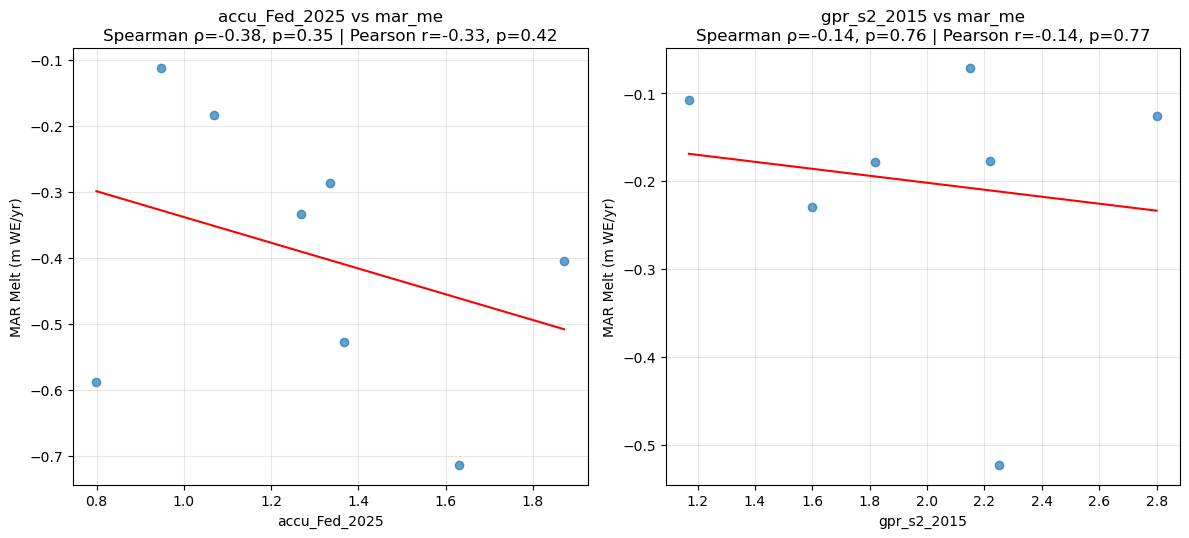

In [230]:
df = ds_obs.copy()

y = df["mar_me"]

variables = ["accu_Fed_2025", "gpr_s2_2015"]

plt.figure(figsize=(12, 10))

results = []

for i, var in enumerate(variables):

    x = df[var]

    # =========================
    # exclusion spécifique
    # =========================
    if var == "accu_Fed_2025":
        x = x.iloc[1:]      # enlève seulement le premier point
        y_tmp = y.iloc[1:]
    else:
        y_tmp = y

    # clean NaN
    mask = ~x.isna() & ~y_tmp.isna()
    x_clean = x[mask]
    y_clean = y_tmp[mask]

    if len(x_clean) < 3:
        continue

    # Spearman correlation
    rho, p_spearman = spearmanr(x_clean, y_clean)

    # regression
    res = linregress(x_clean, y_clean)

    results.append({
        "variable": var,
        "spearman_rho": rho,
        "spearman_p": p_spearman,
        "pearson_r": res.rvalue,
        "pearson_p": res.pvalue
    })

    # subplot
    plt.subplot(2, 2, i + 1)

    plt.scatter(x_clean, y_clean, alpha=0.7)

    # regression line
    x_line = np.linspace(x_clean.min(), x_clean.max(), 100)
    y_line = res.intercept + res.slope * x_line
    plt.plot(x_line, y_line, color="red")

    plt.title(
        f"{var} vs mar_me\n"
        f"Spearman ρ={rho:.2f}, p={p_spearman:.2g} | "
        f"Pearson r={res.rvalue:.2f}, p={res.pvalue:.2g}"
    )

    plt.xlabel(var)
    plt.ylabel("MAR Melt (m WE/yr)")
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()